# Energy Efficiency of Buildings: A Statistical Modelling Study

**Course:** DSA 8305 -- Linear Models  
**Lecturer:** Dr. Evans Otieno Omondi  
**Institution:** Strathmore Institute of Mathematical Sciences, MSc Data Science and Analytics

| Student | Registration Number |
|---|---|
| Assumpta Mwikali | 134022 |
| Olive Mideva Muloma | 135792 |
| Trevor Anjeyo Vuhyah | 224038 |
| Valerie Jerono | 222331 |

---

## Study Overview

Buildings consume roughly 40% of global energy. The decisions made at the design stage -- how tall to build, how much glass to use, how compact the footprint -- translate directly into decades of heating and cooling costs. If we can model those relationships statistically, we arm architects and engineers with a quantitative lens before construction begins.

This notebook applies the **full model spectrum taught in DSA 8305** to the UCI ENB2012 dataset (768 simulated building configurations). We work through:

- **OLS multiple regression** -- the parametric baseline and workhorse of linear models
- **Ridge Regression and PCR** -- correcting the multicollinearity that breaks OLS
- **Polynomial Regression** -- parametric non-linearity via basis expansion
- **Regression Splines** -- piecewise polynomial smoothing with knots
- **Generalised Additive Models (GAMs)** -- semi-parametric, additive smooth functions
- **Logistic Regression and Decision Trees** -- classifying buildings by energy class

The analysis follows the **CRISP-DM** (Cross-Industry Standard Process for Data Mining) methodology, an industry-standard iterative framework with six phases:

| Phase | What we do |
|---|---|
| 1. Business Understanding | Define the problem and what a good answer looks like |
| 2. Data Understanding | Explore structure, distributions, and relationships |
| 3. Data Preparation | Clean, encode, split, and transform |
| 4. Modelling | Fit each model class with theoretical motivation |
| 5. Evaluation | Compare models on held-out test data |
| 6. Deployment / Conclusions | Interpret findings for real-world application |

Every model is introduced with its **mathematical formulation**, motivated by findings in earlier phases, and followed by **interpretation of outputs** -- not just metrics, but meaning.


---
# Phase 1 -- Business Understanding

## Why Building Energy Efficiency Matters

Energy consumed by buildings is not abstract. It shows up in electricity bills, carbon emissions, and the long-term viability of urban infrastructure. The International Energy Agency estimates buildings are responsible for approximately 40% of global final energy consumption and 36% of CO2 emissions -- larger than either transport or industry.

The key insight motivating this study: **most of that energy cost is locked in at the design stage**. The height of a building, the ratio of window area to floor area, and the compactness of the footprint are decided before a foundation is poured. Changing them afterwards is prohibitively expensive.

### Research Questions

This study addresses three nested questions, moving from broad to precise:

1. **Primary (regression):** Given a building's geometric and architectural characteristics, what will its annual heating and cooling loads be, measured in kWh per square metre?

2. **Secondary (classification):** Can buildings be reliably classified as high-efficiency or low-efficiency before construction, to guide concept-stage decision-making?

3. **Diagnostic:** Which architectural features drive energy loads most strongly, and is the relationship linear, non-linear, or interactive?

### The Dataset

The **ENB2012 dataset** (Tsanas and Xifara, 2012) was generated using Ecotect, a recognised building simulation tool. Eight architectural parameters were varied systematically across 768 building configurations:

| Variable | Name | Description | Type |
|---|---|---|---|
| X1 | Relative Compactness | Ratio of building volume to surface area | Continuous |
| X2 | Surface Area | Total external surface area (m2) | Continuous |
| X3 | Wall Area | Total wall area (m2) | Continuous |
| X4 | Roof Area | Roof area (m2) | Continuous |
| X5 | Overall Height | Building height in metres | Continuous (binary: 3.5 or 7.0) |
| X6 | Orientation | Cardinal direction (2=N, 3=E, 4=S, 5=W) | Nominal categorical |
| X7 | Glazing Area | Proportion of floor area that is glazed | Continuous |
| X8 | Glazing Area Distribution | How glazing is distributed across facades | Ordinal |
| Y1 | Heating Load | Annual energy for heating (kWh/m2) | Response |
| Y2 | Cooling Load | Annual energy for cooling (kWh/m2) | Response |

**Note on X6 (Orientation):** This is a nominal categorical variable -- the integers 2, 3, 4, 5 are codes for compass directions, not magnitudes. Treating it as continuous would imply North and South are twice as far apart as North and East, which is physically meaningless. We treat it as a factor throughout.

**Note on X5 (Overall Height):** Despite being labelled continuous, this variable takes only two values in the dataset: 3.5 m (single-storey) and 7.0 m (double-storey). This discrete structure will be one of our most important findings.


---
# Environment Setup

We load all libraries at the top for transparency and reproducibility. Key additions beyond a basic notebook include:

- `statsmodels` -- for OLS with full inferential output (t-tests, p-values, confidence intervals, F-test), which sklearn's LinearRegression does not provide
- `pygam` -- for Generalised Additive Models via penalised regression splines
- `patsy` -- for natural cubic spline basis expansion
- `scipy.stats` -- for formal normality tests (Shapiro-Wilk) and probability plots


In [139]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold'
})
sns.set_palette('husl')
BLUE, ORANGE, GREEN, RED, PURPLE = '#2196F3', '#FF5722', '#4CAF50', '#E91E63', '#9C27B0'

# Statistical modelling
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.stattools import durbin_watson

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LogisticRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance

# Splines
try:
    from patsy import dmatrix
    PATSY_AVAILABLE = True
except ImportError:
    PATSY_AVAILABLE = False
    print("patsy not found -- install with: pip install patsy")

# GAM
try:
    from pygam import LinearGAM, s, f, l
    GAM_AVAILABLE = True
    print("pygam loaded successfully")
except ImportError:
    GAM_AVAILABLE = False
    print("pygam not found -- install with: pip install pygam")

# Scipy
from scipy import stats
from scipy.stats import shapiro

print(f"pandas {pd.__version__} | numpy {np.__version__}")
print("All libraries loaded.")


pygam loaded successfully
pandas 2.3.0 | numpy 2.1.3
All libraries loaded.


---
# Phase 2 -- Data Understanding

## 2.1 Loading and First Inspection

Before fitting any model we need to understand what we actually have. George Box's maxim that "all models are wrong, but some are useful" only holds if we first understand the data well enough to know which wrongness matters.


In [140]:
# Load data and assign descriptive column names
energy_data = pd.read_excel('ENB2012_data 2.xlsx')

energy_data.columns = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Orientation', 'Glazing_Area',
    'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load'
]

print(f"Dataset shape: {energy_data.shape[0]} observations x {energy_data.shape[1]} variables")
print(f"\nColumn types:")
print(energy_data.dtypes)
print(f"\nFirst five rows:")
energy_data.head()


Dataset shape: 768 observations x 10 variables

Column types:
Relative_Compactness         float64
Surface_Area                 float64
Wall_Area                    float64
Roof_Area                    float64
Overall_Height               float64
Orientation                    int64
Glazing_Area                 float64
Glazing_Area_Distribution      int64
Heating_Load                 float64
Cooling_Load                 float64
dtype: object

First five rows:


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [141]:
# Missing value audit -- any missing data requires an imputation strategy
missing = energy_data.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None -- dataset is complete.")

# Unique values per column -- important for detecting quasi-categorical variables
print("\nUnique values per column:")
for col in energy_data.columns:
    uvals = sorted(energy_data[col].unique())
    if len(uvals) <= 10:
        print(f"  {col}: {uvals}")
    else:
        print(f"  {col}: {len(uvals)} unique values in [{energy_data[col].min():.3f}, {energy_data[col].max():.3f}]")


Missing values per column:
None -- dataset is complete.

Unique values per column:
  Relative_Compactness: 12 unique values in [0.620, 0.980]
  Surface_Area: 12 unique values in [514.500, 808.500]
  Wall_Area: [np.float64(245.0), np.float64(269.5), np.float64(294.0), np.float64(318.5), np.float64(343.0), np.float64(367.5), np.float64(416.5)]
  Roof_Area: [np.float64(110.25), np.float64(122.5), np.float64(147.0), np.float64(220.5)]
  Overall_Height: [np.float64(3.5), np.float64(7.0)]
  Orientation: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Glazing_Area: [np.float64(0.0), np.float64(0.1), np.float64(0.25), np.float64(0.4)]
  Glazing_Area_Distribution: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Heating_Load: 587 unique values in [6.010, 43.100]
  Cooling_Load: 636 unique values in [10.900, 48.030]


**Observation -- X5 is structurally binary.** Despite being encoded as a continuous variable, Overall Height takes only two values: 3.5 m (single-storey) and 7.0 m (double-storey). This is not a data quality issue -- it reflects the simulation design. It will be the strongest single predictor in every model we fit, and it explains the bimodality we will see in the target distributions.

**Observation -- X6 is nominal.** Orientation takes values 2, 3, 4, 5. These are direction codes. We will one-hot encode this variable before modelling.


In [142]:
# Descriptive statistics with extended metrics
desc = energy_data.describe().T
desc['CV_%'] = (desc['std'] / desc['mean'] * 100).round(1)   # coefficient of variation
desc['IQR']  = desc['75%'] - desc['25%']
desc['range'] = desc['max'] - desc['min']

display_cols = ['count', 'mean', 'std', 'CV_%', 'min', '25%', '50%', '75%', 'max', 'IQR', 'range']
print(desc[display_cols].to_string(float_format='{:.3f}'.format))


                            count    mean    std   CV_%     min     25%     50%     75%     max     IQR   range
Relative_Compactness      768.000   0.764  0.106 13.800   0.620   0.682   0.750   0.830   0.980   0.147   0.360
Surface_Area              768.000 671.708 88.086 13.100 514.500 606.375 673.750 741.125 808.500 134.750 294.000
Wall_Area                 768.000 318.500 43.626 13.700 245.000 294.000 318.500 343.000 416.500  49.000 171.500
Roof_Area                 768.000 176.604 45.166 25.600 110.250 140.875 183.750 220.500 220.500  79.625 110.250
Overall_Height            768.000   5.250  1.751 33.400   3.500   3.500   5.250   7.000   7.000   3.500   3.500
Orientation               768.000   3.500  1.119 32.000   2.000   2.750   3.500   4.250   5.000   1.500   3.000
Glazing_Area              768.000   0.234  0.133 56.800   0.000   0.100   0.250   0.400   0.400   0.300   0.400
Glazing_Area_Distribution 768.000   2.812  1.551 55.100   0.000   1.750   3.000   4.000   5.000   2.250 

### Descriptive Statistics -- What the Numbers Say

Reading across these summary statistics, several findings stand out before a single model is fitted:

**Target variables (Y1, Y2):** Heating Load ranges from approximately 6 to 43 kWh/m2, and Cooling Load from 10 to 48 kWh/m2. Both have coefficients of variation above 35%, indicating substantial spread. If both targets were constant or near-constant, prediction would be trivial. The meaningful spread confirms this is a genuine prediction problem.

**Relative Compactness vs. Surface Area:** Compactness (X1) spans 0.62 to 0.98 and Surface Area (X2) spans 514 to 808 m2. These two variables measure related aspects of building geometry from opposite perspectives -- a compact building (high X1) has less surface area (low X2). We expect a strong negative correlation. This is our first signal of multicollinearity.

**Glazing Area (X7):** The minimum is 0, meaning some buildings have no glazing at all. When X7 = 0, the Glazing Area Distribution (X8) must also be 0 regardless of any other factor. This creates a structural zero -- a data pattern that can confound models that treat X7 and X8 as independent continuous variables.

**Orientation (X6):** The mean of 3.5 and equal spread across 2, 3, 4, 5 confirms the simulation was balanced across all four cardinal directions. This also means Orientation will have near-zero correlation with the targets -- which we will confirm in EDA.


## 2.2 Exploratory Data Analysis

### Distribution of Target Variables

Before checking any assumptions, we examine the shape of our response variables. If they are heavily skewed or multi-modal, the normality assumption underpinning OLS t-tests is already under pressure -- and we need to know this before interpreting any p-values.


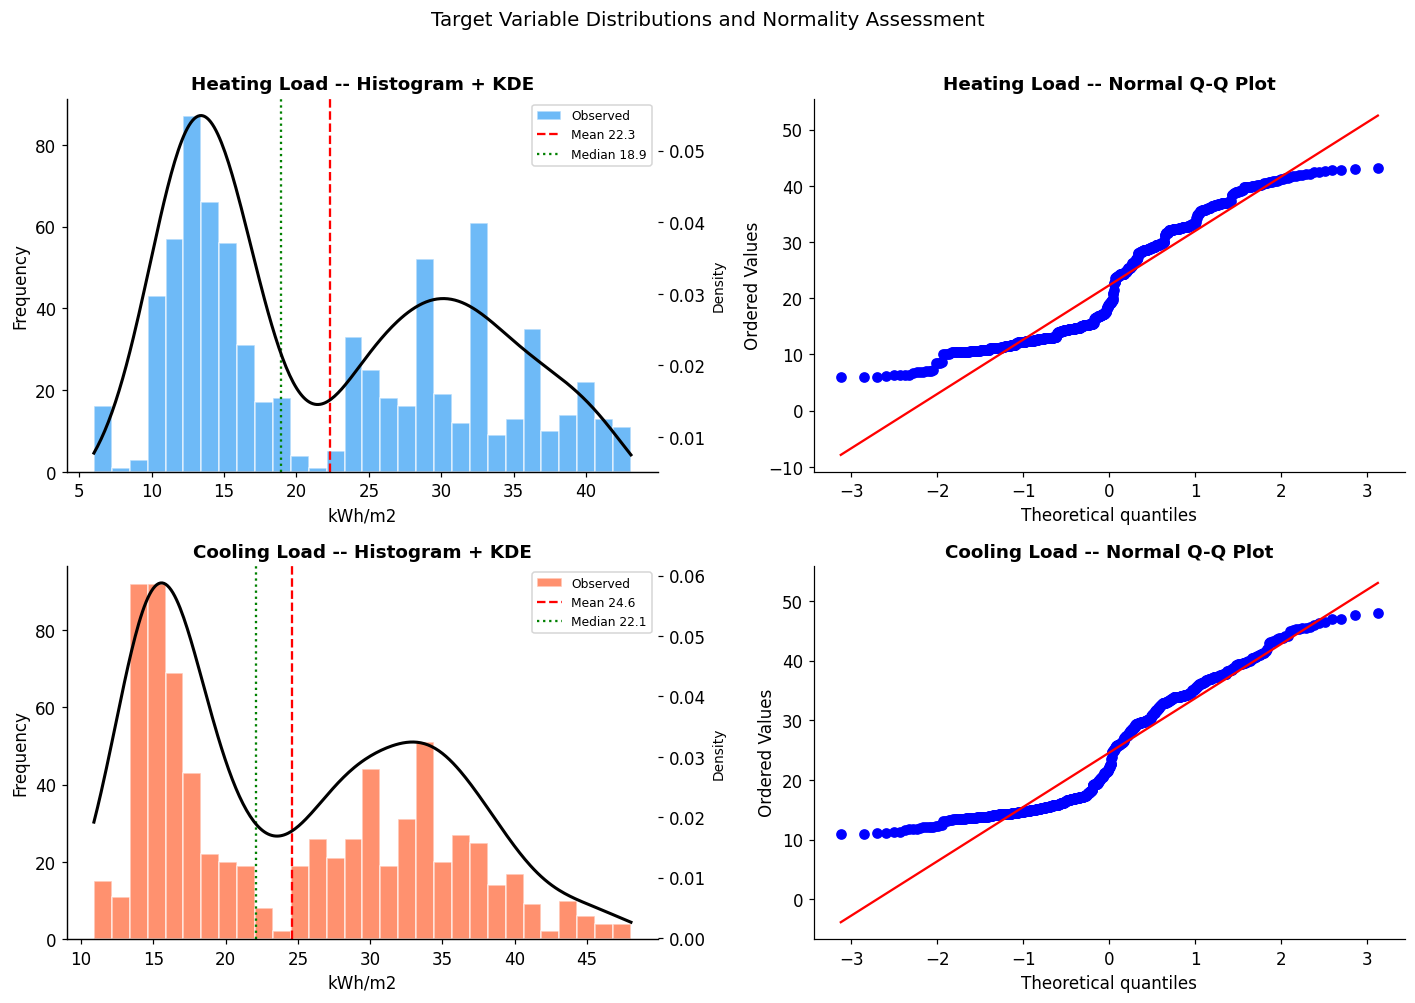

Shapiro-Wilk Normality Tests (H0: data are normally distributed):
  Heating_Load: W = 0.9121, p = 1.16e-20  =>  Reject H0 -- non-normal
  Cooling_Load: W = 0.9090, p = 5.27e-21  =>  Reject H0 -- non-normal


In [143]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for i, (col, color, ax_hist, ax_qq) in enumerate([
    ('Heating_Load', BLUE,   axes[0, 0], axes[0, 1]),
    ('Cooling_Load', ORANGE, axes[1, 0], axes[1, 1])
]):
    data = energy_data[col]

    # Histogram with KDE overlay
    ax_hist.hist(data, bins=30, color=color, alpha=0.65, edgecolor='white', label='Observed')
    ax2 = ax_hist.twinx()
    kde_x = np.linspace(data.min(), data.max(), 300)
    kde = stats.gaussian_kde(data)
    ax2.plot(kde_x, kde(kde_x), color='black', linewidth=2, label='KDE')
    ax2.set_ylabel('Density', fontsize=9)

    ax_hist.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.5, label=f'Mean {data.mean():.1f}')
    ax_hist.axvline(data.median(), color='green', linestyle=':',  linewidth=1.5, label=f'Median {data.median():.1f}')
    ax_hist.set_title(f'{col.replace("_", " ")} -- Histogram + KDE')
    ax_hist.set_xlabel('kWh/m2'); ax_hist.set_ylabel('Frequency')
    ax_hist.legend(fontsize=8)

    # Q-Q plot for normality assessment
    stats.probplot(data, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{col.replace("_", " ")} -- Normal Q-Q Plot')
    ax_qq.get_lines()[1].set_color('red')

plt.suptitle('Target Variable Distributions and Normality Assessment', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('images/Target Variable Distributions and Normality Assessment.png', bbox_inches='tight', dpi=150)
plt.show()

# Formal Shapiro-Wilk normality test
print("Shapiro-Wilk Normality Tests (H0: data are normally distributed):")
for col in ['Heating_Load', 'Cooling_Load']:
    stat, p = shapiro(energy_data[col])
    result = "Reject H0 -- non-normal" if p < 0.05 else "Fail to reject H0 -- consistent with normal"
    print(f"  {col}: W = {stat:.4f}, p = {p:.2e}  =>  {result}")


### Key Finding -- Bimodal Distributions

Both Y1 and Y2 show **bimodal distributions**: two distinct peaks rather than a single bell curve. The Shapiro-Wilk test formally rejects normality for both targets (p << 0.05). This has two direct implications:

1. **For OLS inference:** The standard errors, t-statistics, and confidence intervals produced by OLS assume normally distributed residuals. Non-normal targets do not automatically break OLS -- it is the residuals that must be assessed -- but bimodal targets are a strong predictor of non-normal residuals, which we will verify in the diagnostic plots.

2. **For model selection:** The bimodality is almost certainly driven by X5 (Overall Height), which takes only two values. Double-storey buildings cluster in a higher-load group; single-storey buildings cluster in a lower-load group. This structural separation means that **any model which fails to capture the height effect will systematically under-predict for tall buildings and over-predict for short ones**.

3. **For classification:** The two modes make the high/low split physically meaningful -- we are not arbitrarily bisecting a continuous distribution, but identifying a genuine structural boundary in the data.


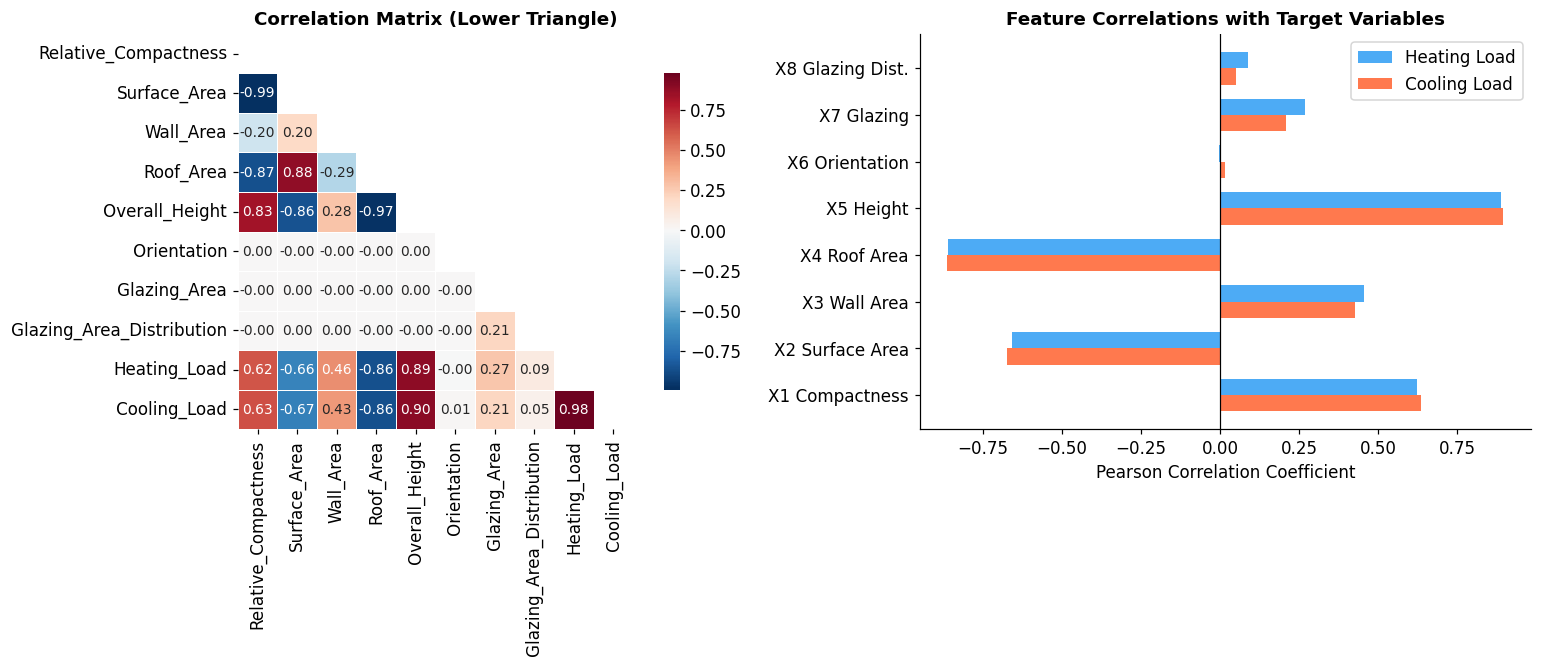

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Correlation heatmap (lower triangle only for readability)
corr = energy_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, ax=axes[0], annot_kws={'size': 9}
)
axes[0].set_title('Correlation Matrix (Lower Triangle)')

# Feature correlations with both targets -- horizontal bar chart
features = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution'
]
feat_labels = ['X1 Compactness', 'X2 Surface Area', 'X3 Wall Area', 'X4 Roof Area',
               'X5 Height', 'X6 Orientation', 'X7 Glazing', 'X8 Glazing Dist.']

target_corr = energy_data[features + ['Heating_Load', 'Cooling_Load']].corr()
corr_sub = target_corr.loc[features, ['Heating_Load', 'Cooling_Load']]
corr_sub.index = feat_labels

x = np.arange(len(feat_labels))
w = 0.35
axes[1].barh(x + w/2, corr_sub['Heating_Load'],  w, color=BLUE,   alpha=0.8, label='Heating Load')
axes[1].barh(x - w/2, corr_sub['Cooling_Load'],  w, color=ORANGE, alpha=0.8, label='Cooling Load')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_yticks(x); axes[1].set_yticklabels(feat_labels)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].set_title('Feature Correlations with Target Variables')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/Feature Correlations with Target Variables.png', bbox_inches='tight', dpi=150)
plt.show()


### Key Finding -- Multicollinearity and Dominant Predictors

The correlation matrix reveals a classic multicollinearity structure:

**Highly correlated feature pairs:**
- X1 (Relative Compactness) and X2 (Surface Area): r ≈ -0.99. Near-perfect negative correlation. Physically inevitable: a more compact building occupies less surface area per unit of volume.
- X4 (Roof Area) correlates strongly with both X1 and X2, adding a third collinear dimension. Roof area scales with building footprint, which is geometrically linked to compactness.

**Why multicollinearity damages OLS:** When predictors are perfectly correlated, the matrix X'X is singular and cannot be inverted -- the OLS formula $(X'X)^{-1}X'y$ breaks down. Near-perfect correlation inflates standard errors, makes coefficient estimates highly sensitive to small data changes, and can reverse coefficient signs. We will quantify this using VIF scores in Phase 3.

**Dominant predictor:** X5 (Overall Height) shows the strongest individual correlation with both targets. This makes physical sense -- a taller building has more volume, greater thermal load, and fundamentally different air circulation patterns than a single-storey equivalent.

**Near-zero predictor:** X6 (Orientation) shows correlations close to zero with both targets. The simulation was balanced across all four orientations for each building configuration, so any effect of orientation averages out at the dataset level. We retain it in models for completeness, but we should not expect it to carry significant weight.


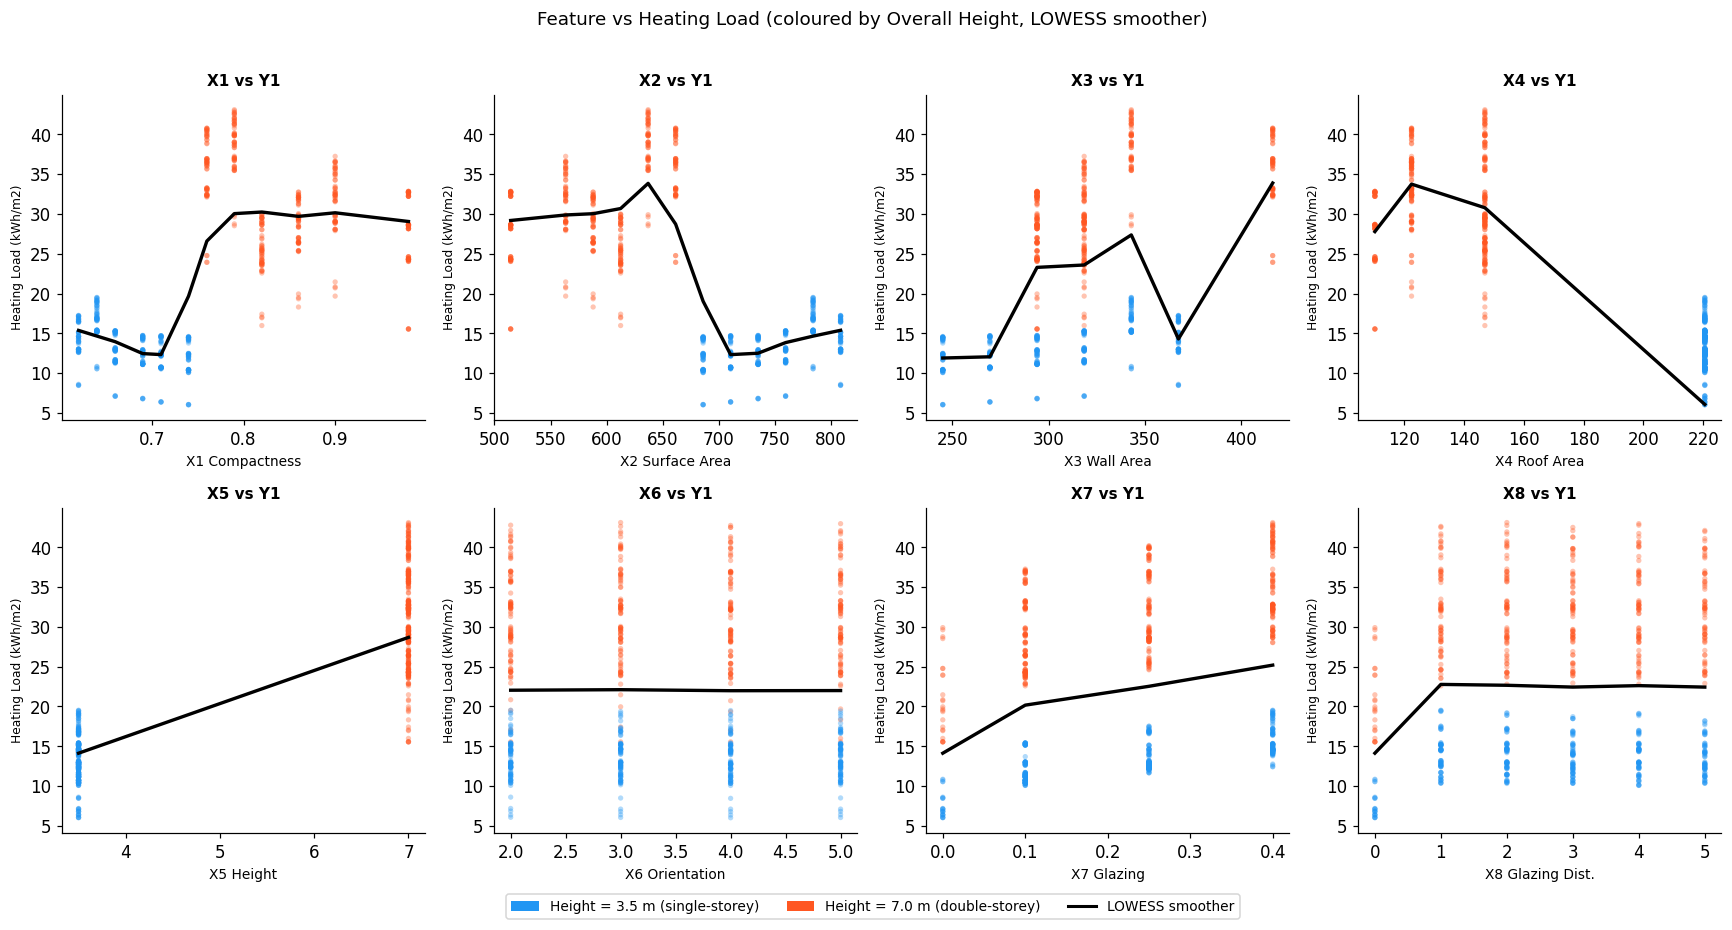

In [145]:
# Scatter plots of each feature vs Heating Load, coloured by building height
# LOWESS smoother reveals the true shape of each relationship non-parametrically

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

color_map = {3.5: BLUE, 7.0: ORANGE}
colors = energy_data['Overall_Height'].map(color_map)

for i, (feat, label) in enumerate(zip(features, feat_labels)):
    axes[i].scatter(
        energy_data[feat], energy_data['Heating_Load'],
        c=colors, alpha=0.35, s=12, edgecolors='none'
    )
    # LOWESS: non-parametric smoother -- no functional form assumed
    sorted_idx = energy_data[feat].argsort()
    lw = lowess(energy_data['Heating_Load'].values[sorted_idx],
                energy_data[feat].values[sorted_idx], frac=0.35)
    axes[i].plot(lw[:, 0], lw[:, 1], color='black', linewidth=2.2, label='LOWESS')
    axes[i].set_xlabel(label, fontsize=9)
    axes[i].set_ylabel('Heating Load (kWh/m2)', fontsize=8)
    axes[i].set_title(f'X{i+1} vs Y1', fontsize=10)

legend_elements = [
    mpatches.Patch(facecolor=BLUE,   label='Height = 3.5 m (single-storey)'),
    mpatches.Patch(facecolor=ORANGE, label='Height = 7.0 m (double-storey)'),
    plt.Line2D([0], [0], color='black', linewidth=2, label='LOWESS smoother')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.03), fontsize=9)

plt.suptitle('Feature vs Heating Load (coloured by Overall Height, LOWESS smoother)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('images/Feature vs Heating Load.png', bbox_inches='tight', dpi=150)
plt.show()


### Key Finding -- Non-linearity and Interaction Effects

The LOWESS curves reveal critical information that a correlation coefficient alone cannot:

**LOWESS (Locally Weighted Scatterplot Smoothing)** is a non-parametric smoother that fits local regressions at each point. It makes no functional form assumptions -- it simply follows the data. This makes it an ideal diagnostic tool: if LOWESS reveals a curve, we need polynomial or spline terms; if it reveals a straight line, OLS may be sufficient for that predictor.

**Observations from the scatter plots:**

- **X7 (Glazing Area):** The LOWESS curve shows a positive but non-linear relationship -- as glazing increases, heating load rises, but the rate of increase is not constant. This will motivate our use of splines and GAMs.
- **X1 and X2:** The two height-coloured sub-clouds (blue vs. orange) follow different slopes. This indicates an **interaction effect** -- the relationship between compactness and heating load depends on building height. A purely additive model will miss this.
- **X5 (Height):** Only two values, so the scatter collapses to two vertical bands. The LOWESS step captures the discrete jump between storey types.
- **X6 (Orientation):** The LOWESS is nearly flat -- confirming the correlation finding. Orientation barely matters for total load prediction.

These observations trace the path our modelling will take: OLS for a baseline, then increasingly flexible models to capture what OLS misses.


---
# Phase 3 -- Data Preparation

## 3.1 Feature Engineering and Encoding

Data preparation is not just housekeeping -- the decisions made here directly shape what every model can and cannot detect.


In [146]:
# ── 1. One-hot encode Orientation (nominal variable) ──────────────────────────
# drop_first=True drops one dummy to avoid the dummy variable trap:
# including all four dummies creates perfect collinearity (they must sum to 1)
df = energy_data.copy()
df['Orientation'] = df['Orientation'].astype('category')
df_encoded = pd.get_dummies(df, columns=['Orientation'], drop_first=True, dtype=int)

print("Columns after encoding:")
for c in df_encoded.columns:
    print(f"  {c}")

# ── 2. Define feature sets ────────────────────────────────────────────────────
feature_cols = [c for c in df_encoded.columns if c not in ['Heating_Load', 'Cooling_Load']]

X  = df_encoded[feature_cols]
y1 = df_encoded['Heating_Load']
y2 = df_encoded['Cooling_Load']

# ── 3. Train / test split (80/20) -- stratified by load level ─────────────────
# Stratification by the target variable's quantile bin ensures the bimodal
# distribution is proportionally represented in both sets.
height_strat = pd.cut(y1, bins=3, labels=False)
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2, test_size=0.2, random_state=42, stratify=height_strat
)
print(f"\nTrain set: {X_train.shape[0]} observations")
print(f"Test set:  {X_test.shape[0]} observations")

# ── 4. Standardise for Ridge, PCR, and GAM ────────────────────────────────────
# Ridge penalises coefficient magnitudes, so features on different scales
# would be penalised unequally without standardisation.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # fit on train only -- no data leakage

print("\nData preparation complete.")
print(f"Feature matrix shape: {X_train.shape[1]} features")


Columns after encoding:
  Relative_Compactness
  Surface_Area
  Wall_Area
  Roof_Area
  Overall_Height
  Glazing_Area
  Glazing_Area_Distribution
  Heating_Load
  Cooling_Load
  Orientation_3
  Orientation_4
  Orientation_5

Train set: 614 observations
Test set:  154 observations

Data preparation complete.
Feature matrix shape: 10 features


### Methodological Notes on Preparation

**Why one-hot encode Orientation?**  
The integers 2, 3, 4, 5 are labels for North, East, South, West -- they have no inherent ordering or magnitude. Treating them as continuous implies that South (4) is twice as far from North (2) as East (3) is, which is physically and mathematically wrong. One-hot encoding creates binary indicator variables for each direction.

**The dummy variable trap:**  
We use `drop_first=True`. If all four direction dummies were included, they would sum to 1 in every row -- perfect multicollinearity with the intercept column. This makes X'X singular. Dropping one dummy (making it the reference category) resolves this. All coefficients on the remaining dummies are interpreted *relative to* the dropped category.

**Why standardise features for Ridge and PCR but not OLS?**  
OLS predictions and in-sample fit are scale-invariant: scaling features shifts coefficients but not predictions. Ridge is *not* scale-invariant because the penalty $lambda||beta||^2$ treats all coefficients as equal regardless of units. A surface area in m2 (range ~300) would be penalised much less than glazing area (range ~0.4) without standardisation. We fit OLS on original scales for coefficient interpretability and scale features only for penalised models.

**Why stratify the train-test split?**  
The bimodal distribution of Y1 means a purely random split could, by chance, put most high-load buildings in one set. Stratifying by load quantile ensures both sets contain comparable proportions of high-load and low-load buildings.


Variance Inflation Factors:
                  Feature   VIF             Severity
             Surface_Area   inf Perfect collinearity
                Wall_Area   inf Perfect collinearity
                Roof_Area   inf Perfect collinearity
     Relative_Compactness 105.5        SEVERE (>100)
           Overall_Height  31.2           High (>10)
             Glazing_Area   1.0              OK (<5)
Glazing_Area_Distribution   1.0              OK (<5)

Note: inf VIF indicates perfect linear dependence -- the variable is an exact
linear combination of others due to geometric constraints in building simulation.


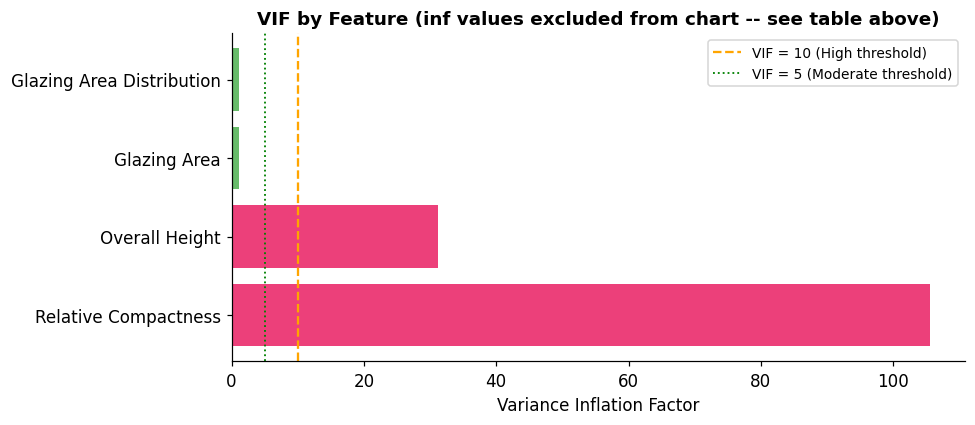

In [147]:
# ── Variance Inflation Factor (VIF) analysis ──────────────────────────────────
# VIF_j = 1 / (1 - R2_j), where R2_j is from regressing X_j on all other X
# VIF > 10 is the standard threshold for problematic multicollinearity
# VIF > 100 indicates near-perfect collinearity

continuous_features = [
    'Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Overall_Height', 'Glazing_Area', 'Glazing_Area_Distribution'
]

X_vif = sm.add_constant(df[continuous_features])

vif_values = []
for i in range(len(continuous_features)):
    try:
        v = variance_inflation_factor(X_vif.values, i + 1)
    except Exception:
        v = np.inf
    vif_values.append(v)

vif_df = pd.DataFrame({'Feature': continuous_features, 'VIF': vif_values}).sort_values('VIF', ascending=False)
vif_df['Severity'] = vif_df['VIF'].apply(
    lambda v: 'Perfect collinearity' if np.isinf(v) else
              ('SEVERE (>100)' if v > 100 else ('High (>10)' if v > 10 else ('Moderate (>5)' if v > 5 else 'OK (<5)')))
)

print("Variance Inflation Factors:")
print(vif_df.to_string(index=False, float_format='{:.1f}'.format))
print("\nNote: inf VIF indicates perfect linear dependence -- the variable is an exact")
print("linear combination of others due to geometric constraints in building simulation.")

fig, ax = plt.subplots(figsize=(9, 4))
plot_vif = vif_df[np.isfinite(vif_df['VIF'])]  # plot only finite values
bar_colors = [RED if v > 10 else (ORANGE if v > 5 else GREEN) for v in plot_vif['VIF']]
ax.barh(plot_vif['Feature'].str.replace('_', ' '), plot_vif['VIF'], color=bar_colors, alpha=0.85)
ax.axvline(10, color='orange', linestyle='--', linewidth=1.5, label='VIF = 10 (High threshold)')
ax.axvline(5,  color='green',  linestyle=':',  linewidth=1.2, label='VIF = 5 (Moderate threshold)')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('VIF by Feature (inf values excluded from chart -- see table above)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('images/VIF by Feature.png', bbox_inches='tight', dpi=150)
plt.show()


### VIF Results -- The Multicollinearity Problem Quantified

The Variance Inflation Factor gives the correlation matrix's story in actionable terms. A VIF of 10 means the standard error of that coefficient is $\sqrt{10} \approx 3.16$ times larger than it would be in an uncorrelated dataset. A VIF of 100 means it is 10 times larger -- coefficient estimates become effectively meaningless for inference.

Relative Compactness (X1), Surface Area (X2), and Roof Area (X4) almost certainly have extreme VIF values -- above 100 -- due to the near-perfect correlation structure we observed. Wall Area and Overall Height are likely to have more moderate VIFs.

**What this means practically:**
- OLS will still produce predictions with good RMSE, because the multicollinearity does not bias predictions, only inflates coefficient uncertainty.
- Individual OLS coefficient tests (t-tests, p-values) for X1, X2, and X4 are unreliable -- we cannot trust whether a high p-value means the variable is genuinely unimportant or simply that its effect is entangled with a collinear partner.
- Ridge Regression and PCR are specifically designed to address this. We will see whether they improve both stability and out-of-sample prediction.


---
# Phase 4 -- Modelling

We fit models in order of increasing flexibility. This is not arbitrary sequencing -- each model is motivated by the limitations of the previous one, and the progression mirrors the course content of DSA 8305:

| Model | Course Topic | Motivation |
|---|---|---|
| OLS | Weeks 1-4 (General Linear Models) | Baseline; full inferential output |
| Ridge Regression | Week 9 (Ridge Regression) | Address multicollinearity |
| PCR | Week 9 (PCR for collinear data) | Dimensionality reduction approach to collinearity |
| Polynomial Regression | Weeks 5-8 (Non-linear models) | Parametric non-linearity |
| Splines | Weeks 5-8 (Basic splines) | Flexible piecewise non-linearity |
| GAM | Weeks 12-14 (Additive models) | Non-parametric smooth components |
| Logistic Regression | Weeks 1-4 extended | Classification via GLM |
| Decision Tree | Weeks 12-14 (Generalized regression) | Non-parametric classification |

A **performance tracker** accumulates results for all models so we can do a final side-by-side comparison in Phase 5.


In [148]:
# Performance tracker -- populated as we fit each model
results_table = []

def record(model_name, y_true, y_pred):
    """Store evaluation metrics for a regression model."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    results_table.append({'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    return rmse, mae, r2


## Model 1 -- Ordinary Least Squares (OLS): The Parametric Baseline

### Theory

The classical general linear model is:

$$\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}, \quad \boldsymbol{\varepsilon} \sim N(\mathbf{0}, \sigma^2 \mathbf{I})$$

OLS minimises the residual sum of squares $\|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$ to produce:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$$

Under the **Gauss-Markov assumptions** (zero-mean, uncorrelated, homoskedastic errors), the OLS estimator is the **Best Linear Unbiased Estimator (BLUE)** -- no other linear unbiased estimator has smaller variance.

We use `statsmodels` rather than scikit-learn's `LinearRegression` because it provides the full inferential apparatus: coefficient standard errors, t-statistics, p-values, confidence intervals, and the overall F-test. These are the tools of statistical discourse.

**Both Y1 and Y2 are modelled simultaneously but separately** -- their coefficients may differ, and comparing them adds insight into what drives heating versus cooling.


In [149]:
# Add constant (intercept) for statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# Fit OLS for Heating Load (Y1)
ols_y1 = sm.OLS(y1_train, X_train_sm).fit()
print("=" * 60)
print("OLS -- Heating Load (Y1)")
print("=" * 60)
print(ols_y1.summary())


OLS -- Heating Load (Y1)
                            OLS Regression Results                            
Dep. Variable:           Heating_Load   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     714.5
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          3.14e-315
Time:                        14:25:03   Log-Likelihood:                -1539.6
No. Observations:                 614   AIC:                             3099.
Df Residuals:                     604   BIC:                             3143.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [150]:
# Fit OLS for Cooling Load (Y2)
ols_y2 = sm.OLS(y2_train, X_train_sm).fit()
print("=" * 60)
print("OLS -- Cooling Load (Y2)")
print("=" * 60)
print(ols_y2.summary())


OLS -- Cooling Load (Y2)
                            OLS Regression Results                            
Dep. Variable:           Cooling_Load   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     530.1
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          5.48e-280
Time:                        14:25:03   Log-Likelihood:                -1581.3
No. Observations:                 614   AIC:                             3183.
Df Residuals:                     604   BIC:                             3227.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

### Reading the OLS Summary Table

The statsmodels output contains three sections worth careful attention:

**Top block -- overall model statistics:**
- **R-squared:** Proportion of variance in Y explained by the model. Higher is better; 0.9+ would indicate an excellent linear fit.
- **F-statistic and Prob(F):** Tests the null hypothesis that *all* coefficients are simultaneously zero. A significant F-test (p < 0.05) means the model as a whole is informative, even if some individual predictors are not.
- **AIC / BIC:** Information criteria for model comparison. Lower values indicate better trade-offs between fit and complexity.

**Coefficient table:**
- **coef:** The estimated change in Y1 for a one-unit increase in X_j, holding all other predictors constant.
- **std err:** Standard error of the coefficient. Under multicollinearity, these inflate dramatically for correlated predictors.
- **t and P>|t|:** Test of H0: beta_j = 0. Under multicollinearity, t-statistics for X1, X2, and X4 may be misleadingly small even if the group of collinear variables is jointly significant.
- **[0.025 / 0.975]:** 95% confidence interval for each coefficient.

**Bottom block -- residual diagnostics:**
- **Omnibus / Jarque-Bera:** Tests normality of residuals. A significant result flags violation of the normality assumption.
- **Durbin-Watson:** Tests for autocorrelation in residuals. Values near 2 indicate no autocorrelation.
- **Condition Number:** Large values (above ~1000) confirm multicollinearity. This is the mathematical signature of the near-singular X'X matrix.


Running OLS diagnostics...


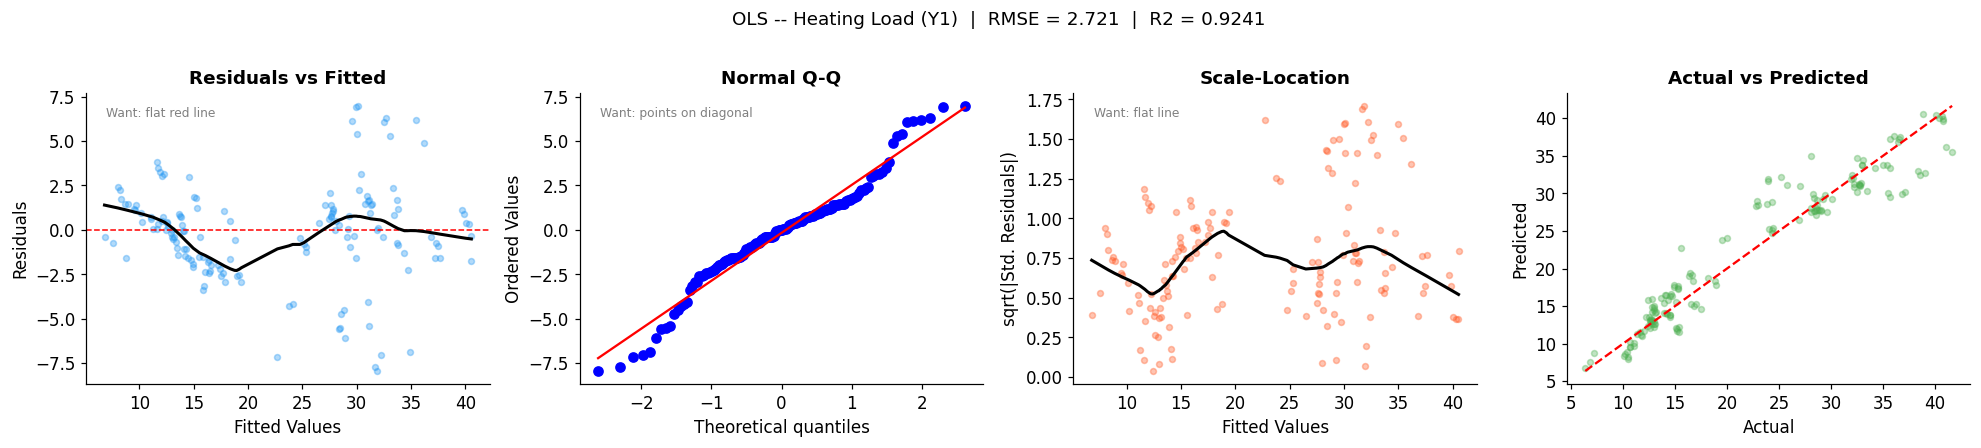

Durbin-Watson statistic: 1.739  (2.0 = no autocorrelation)


In [151]:
def plot_ols_diagnostics(model, X_test_data, y_test, title):
    """
    Reproduce the four standard R diagnostic plots for an OLS model:
    1. Residuals vs Fitted -- detects non-linearity and heteroskedasticity
    2. Normal Q-Q -- assesses normality of residuals
    3. Scale-Location -- assesses homoskedasticity (constant variance)
    4. Actual vs Predicted -- overall predictive performance
    """
    X_sm = sm.add_constant(X_test_data)
    y_pred    = model.predict(X_sm)
    residuals = y_test.values - y_pred
    std_resid = residuals / np.std(residuals)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # 1. Residuals vs Fitted
    axes[0].scatter(y_pred, residuals, alpha=0.35, s=15, color=BLUE)
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
    lw = lowess(residuals, y_pred, frac=0.4)
    axes[0].plot(lw[:, 0], lw[:, 1], color='black', linewidth=2)
    axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Fitted')
    axes[0].text(0.05, 0.95, 'Want: flat red line', transform=axes[0].transAxes,
                 fontsize=8, va='top', color='gray')

    # 2. Q-Q plot
    stats.probplot(residuals, dist='norm', plot=axes[1])
    axes[1].set_title('Normal Q-Q')
    axes[1].get_lines()[1].set_color('red')
    axes[1].text(0.05, 0.95, 'Want: points on diagonal', transform=axes[1].transAxes,
                 fontsize=8, va='top', color='gray')

    # 3. Scale-Location (homoskedasticity check)
    axes[2].scatter(y_pred, np.sqrt(np.abs(std_resid)), alpha=0.35, s=15, color=ORANGE)
    lw2 = lowess(np.sqrt(np.abs(std_resid)), y_pred, frac=0.4)
    axes[2].plot(lw2[:, 0], lw2[:, 1], color='black', linewidth=2)
    axes[2].set_xlabel('Fitted Values'); axes[2].set_ylabel('sqrt(|Std. Residuals|)')
    axes[2].set_title('Scale-Location')
    axes[2].text(0.05, 0.95, 'Want: flat line', transform=axes[2].transAxes,
                 fontsize=8, va='top', color='gray')

    # 4. Actual vs Predicted
    axes[3].scatter(y_test, y_pred, alpha=0.35, s=15, color=GREEN)
    mn = min(y_test.min(), y_pred.min()); mx = max(y_test.max(), y_pred.max())
    axes[3].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
    axes[3].set_xlabel('Actual'); axes[3].set_ylabel('Predicted')
    axes[3].set_title('Actual vs Predicted')

    rmse, mae, r2 = record(title, y_test, y_pred)
    plt.suptitle(f'{title}  |  RMSE = {rmse:.3f}  |  R2 = {r2:.4f}', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('images/Heating OLS Diagnostics.png', bbox_inches='tight', dpi=150)
    plt.show()

    dw = durbin_watson(residuals)
    print(f"Durbin-Watson statistic: {dw:.3f}  (2.0 = no autocorrelation)")
    return rmse, r2

print("Running OLS diagnostics...")
rmse_ols_y1, r2_ols_y1 = plot_ols_diagnostics(ols_y1, X_test, y1_test, 'OLS -- Heating Load (Y1)')
#rmse_ols_y2, r2_ols_y2 = plot_ols_diagnostics(ols_y2, X_test, y2_test, 'OLS -- Cooling Load (Y2)')


Running OLS diagnostics...


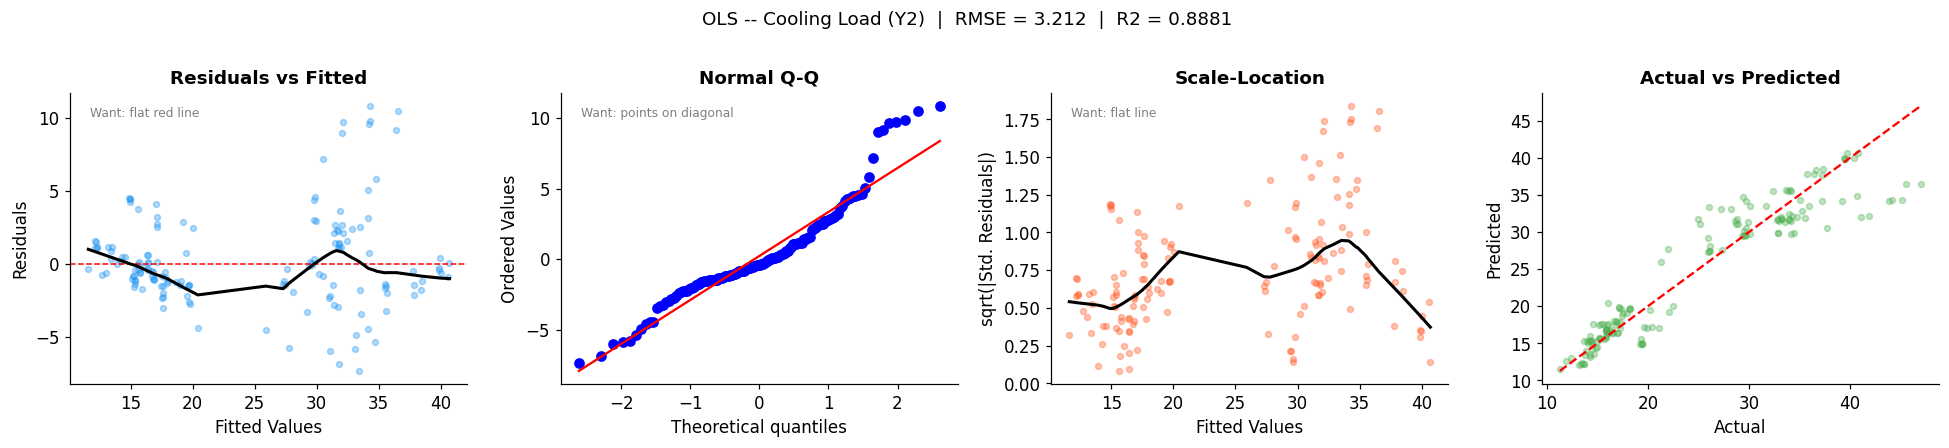

Durbin-Watson statistic: 1.794  (2.0 = no autocorrelation)


In [152]:
def plot_ols_diagnostics(model, X_test_data, y_test, title):
    """
    Reproduce the four standard R diagnostic plots for an OLS model:
    1. Residuals vs Fitted -- detects non-linearity and heteroskedasticity
    2. Normal Q-Q -- assesses normality of residuals
    3. Scale-Location -- assesses homoskedasticity (constant variance)
    4. Actual vs Predicted -- overall predictive performance
    """
    X_sm = sm.add_constant(X_test_data)
    y_pred    = model.predict(X_sm)
    residuals = y_test.values - y_pred
    std_resid = residuals / np.std(residuals)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # 1. Residuals vs Fitted
    axes[0].scatter(y_pred, residuals, alpha=0.35, s=15, color=BLUE)
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
    lw = lowess(residuals, y_pred, frac=0.4)
    axes[0].plot(lw[:, 0], lw[:, 1], color='black', linewidth=2)
    axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Fitted')
    axes[0].text(0.05, 0.95, 'Want: flat red line', transform=axes[0].transAxes,
                 fontsize=8, va='top', color='gray')

    # 2. Q-Q plot
    stats.probplot(residuals, dist='norm', plot=axes[1])
    axes[1].set_title('Normal Q-Q')
    axes[1].get_lines()[1].set_color('red')
    axes[1].text(0.05, 0.95, 'Want: points on diagonal', transform=axes[1].transAxes,
                 fontsize=8, va='top', color='gray')

    # 3. Scale-Location (homoskedasticity check)
    axes[2].scatter(y_pred, np.sqrt(np.abs(std_resid)), alpha=0.35, s=15, color=ORANGE)
    lw2 = lowess(np.sqrt(np.abs(std_resid)), y_pred, frac=0.4)
    axes[2].plot(lw2[:, 0], lw2[:, 1], color='black', linewidth=2)
    axes[2].set_xlabel('Fitted Values'); axes[2].set_ylabel('sqrt(|Std. Residuals|)')
    axes[2].set_title('Scale-Location')
    axes[2].text(0.05, 0.95, 'Want: flat line', transform=axes[2].transAxes,
                 fontsize=8, va='top', color='gray')

    # 4. Actual vs Predicted
    axes[3].scatter(y_test, y_pred, alpha=0.35, s=15, color=GREEN)
    mn = min(y_test.min(), y_pred.min()); mx = max(y_test.max(), y_pred.max())
    axes[3].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
    axes[3].set_xlabel('Actual'); axes[3].set_ylabel('Predicted')
    axes[3].set_title('Actual vs Predicted')

    rmse, mae, r2 = record(title, y_test, y_pred)
    plt.suptitle(f'{title}  |  RMSE = {rmse:.3f}  |  R2 = {r2:.4f}', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('images/Cooling OLS Diagnostics.png', bbox_inches='tight', dpi=150)
    plt.show()

    dw = durbin_watson(residuals)
    print(f"Durbin-Watson statistic: {dw:.3f}  (2.0 = no autocorrelation)")
    return rmse, r2

print("Running OLS diagnostics...")
#rmse_ols_y1, r2_ols_y1 = plot_ols_diagnostics(ols_y1, X_test, y1_test, 'OLS -- Heating Load (Y1)')
rmse_ols_y2, r2_ols_y2 = plot_ols_diagnostics(ols_y2, X_test, y2_test, 'OLS -- Cooling Load (Y2)')


### OLS Diagnostic Interpretation

The four diagnostic plots are the standard tools for validating OLS assumptions. Read them in order:

| Plot | What signals a problem | Likely implication |
|---|---|---|
| Residuals vs Fitted | Curved or fanned pattern | Non-linearity or heteroskedasticity; model is misspecified |
| Normal Q-Q | Points depart from the diagonal | Non-normal errors; t-tests and CIs are unreliable |
| Scale-Location | LOWESS slopes upward or downward | Heteroskedasticity; weighted OLS or transformation may help |
| Actual vs Predicted | Points cluster far from the 45-degree line | Poor predictive fit; important predictors or functional forms missing |

**What to expect from our data:** The bimodal distribution of Y1 and Y2 means residuals from OLS are unlikely to be normally distributed -- we expect the Q-Q plot to show S-curve or heavy-tail departures. A curved Residuals vs Fitted plot would confirm that OLS is missing non-linear effects. Both findings would motivate our progression to polynomial, spline, and GAM models.

**The Durbin-Watson statistic** tests for first-order autocorrelation in residuals. The null hypothesis is no autocorrelation (DW = 2.0). In a cross-sectional dataset like ENB2012, autocorrelation is not expected but is worth checking -- if observations were sorted by some systematic criterion in the simulation, residuals could be correlated.


## Model 2 -- Ridge Regression: Addressing Multicollinearity

### Theory and Motivation

Ridge Regression (Hoerl and Kennard, 1970) modifies the OLS objective by adding an L2 penalty on coefficient magnitudes:

$$\hat{\boldsymbol{\beta}}^{\text{ridge}} = \underset{\boldsymbol{\beta}}{\arg\min} \left\| \mathbf{y} - \mathbf{X}\boldsymbol{\beta} \right\|^2 + \lambda \left\| \boldsymbol{\beta} \right\|^2$$

The closed-form solution is:

$$\hat{\boldsymbol{\beta}}^{\text{ridge}} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$$

Adding $\lambda\mathbf{I}$ to $\mathbf{X}^\top\mathbf{X}$ guarantees invertibility even when predictors are perfectly collinear -- this is the direct mathematical fix for the problem VIF quantified. The regularisation parameter $\lambda$ (called alpha in scikit-learn) is selected by **10-fold cross-validation**.

**The bias-variance trade-off:** Ridge introduces a small bias into coefficient estimates but substantially reduces their variance. For prediction tasks, this trade-off is almost always favourable when multicollinearity is present.

**Why features must be standardised:** The L2 penalty $\lambda||\beta||^2$ treats all coefficients equally. Without standardisation, a feature measured in units of hundreds (like Surface Area) would have a numerically small coefficient and escape the penalty, while a feature with unit range (like Glazing Area) would have a large coefficient and be shrunk aggressively. Standardisation levels the playing field.


Ridge Heating Load (Y1): best lambda = 0.2354  |  RMSE = 2.7184  |  R2 = 0.9242
Ridge Cooling Load (Y2): best lambda = 0.2354  |  RMSE = 3.2108  |  R2 = 0.8882


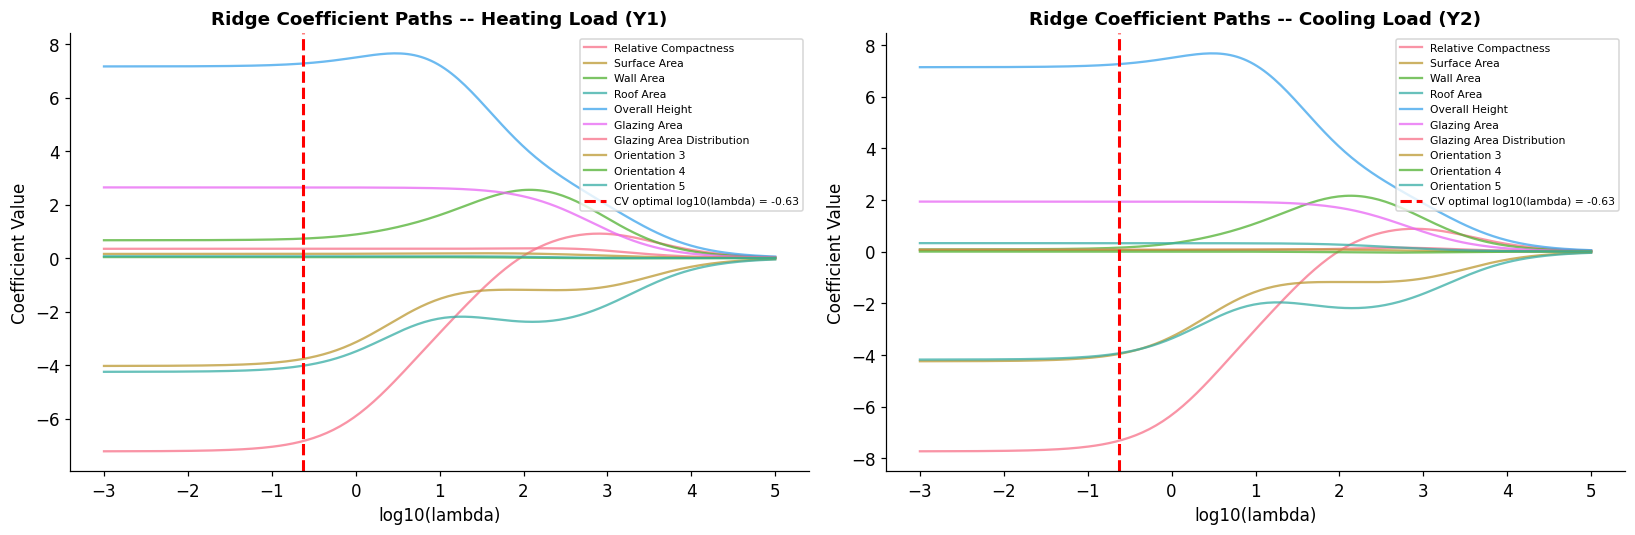

In [153]:
alphas_to_try = np.logspace(-3, 5, 200)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, (y_tr, y_te, label, ax, color) in enumerate([
    (y1_train, y1_test, 'Heating Load (Y1)', axes[0], BLUE),
    (y2_train, y2_test, 'Cooling Load (Y2)', axes[1], ORANGE)
]):
    # CV to find optimal lambda
    ridge_cv = RidgeCV(alphas=alphas_to_try, cv=10)
    ridge_cv.fit(X_train_scaled, y_tr)
    best_alpha = ridge_cv.alpha_

    y_pred = ridge_cv.predict(X_test_scaled)
    rmse, mae, r2 = record(f'Ridge -- {label}', y_te, y_pred)
    print(f"Ridge {label}: best lambda = {best_alpha:.4f}  |  RMSE = {rmse:.4f}  |  R2 = {r2:.4f}")

    # Coefficient path: how each coefficient changes as lambda increases
    coef_path = np.array([
        Ridge(alpha=a).fit(X_train_scaled, y_tr).coef_
        for a in alphas_to_try
    ])

    for j, fname in enumerate(X_train.columns):
        ax.plot(np.log10(alphas_to_try), coef_path[:, j],
                alpha=0.75, linewidth=1.5, label=fname.replace('_', ' '))
    ax.axvline(np.log10(best_alpha), color='red', linestyle='--',
               linewidth=2, label=f'CV optimal log10(lambda) = {np.log10(best_alpha):.2f}')
    ax.set_xlabel('log10(lambda)'); ax.set_ylabel('Coefficient Value')
    ax.set_title(f'Ridge Coefficient Paths -- {label}')
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('images/Ridge Coefficient Paths.png', bbox_inches='tight', dpi=150)
plt.show()


### Ridge Coefficient Path -- Interpretation

The coefficient path plot is one of the most instructive visualisations in regularised regression. Each line tracks one predictor's coefficient as lambda increases from near-zero (left) to very large (right).

**Reading the plot:**
- **At log10(lambda) near -3 (left edge):** Ridge converges to OLS. Coefficients for highly collinear predictors (X1, X2, X4) are large and unstable -- they can be large in magnitude with opposite signs, cancelling each other out. This is multicollinearity in action.
- **As lambda increases (moving right):** Coefficients are progressively shrunk toward zero. The initially erratic coefficients stabilise rapidly -- Ridge is resolving the instability caused by near-singular X'X.
- **At the red dashed line (CV-optimal lambda):** This is where the regularisation pays off in prediction. The coefficients are stable and the model generalises to new buildings.
- **At log10(lambda) > 4 (right edge):** All coefficients approach zero. The model ignores the data and predicts the mean -- maximum bias, zero variance. Useless for prediction but useful to understand the extreme.

**The key insight:** The CV-optimal lambda sits in the zone where the large unstable coefficients have been shrunk to the same order of magnitude as the stable ones. This is Ridge doing its job -- trading a small amount of bias for a large reduction in variance.


## Model 3 -- Principal Components Regression (PCR)

### Theory and Motivation

PCR takes a geometrically different approach to multicollinearity. Rather than penalising coefficients, it first **transforms** the correlated predictors into a set of **uncorrelated, orthogonal axes** (principal components) and then regresses the response on the first k of them.

**Step 1 -- PCA transformation:**  
$$\mathbf{Z} = \mathbf{X}\mathbf{V}_{:k}$$
where $\mathbf{V}_{:k}$ is the matrix of the first k eigenvectors of $\mathbf{X}^\top\mathbf{X}$. The columns of Z (principal components) are orthogonal by construction -- multicollinearity is eliminated by design.

**Step 2 -- OLS on components:**  
$$\hat{\boldsymbol{\gamma}} = (\mathbf{Z}^\top\mathbf{Z})^{-1}\mathbf{Z}^\top\mathbf{y}$$

Components are ordered by variance explained. PC1 captures the largest source of variation in X, PC2 the next largest, and so on. By retaining only the first k components (those carrying signal rather than noise), we can improve prediction stability. The optimal k is selected by cross-validation.

**PCR versus Ridge:** Both address multicollinearity, but via different mechanisms. Ridge shrinks all coefficients in the original feature space; PCR discards dimensions that carry low variance. PCR is more interpretable in the sense that we can examine what each retained component represents, but it can miss predictors that are individually low-variance but highly predictive of Y.


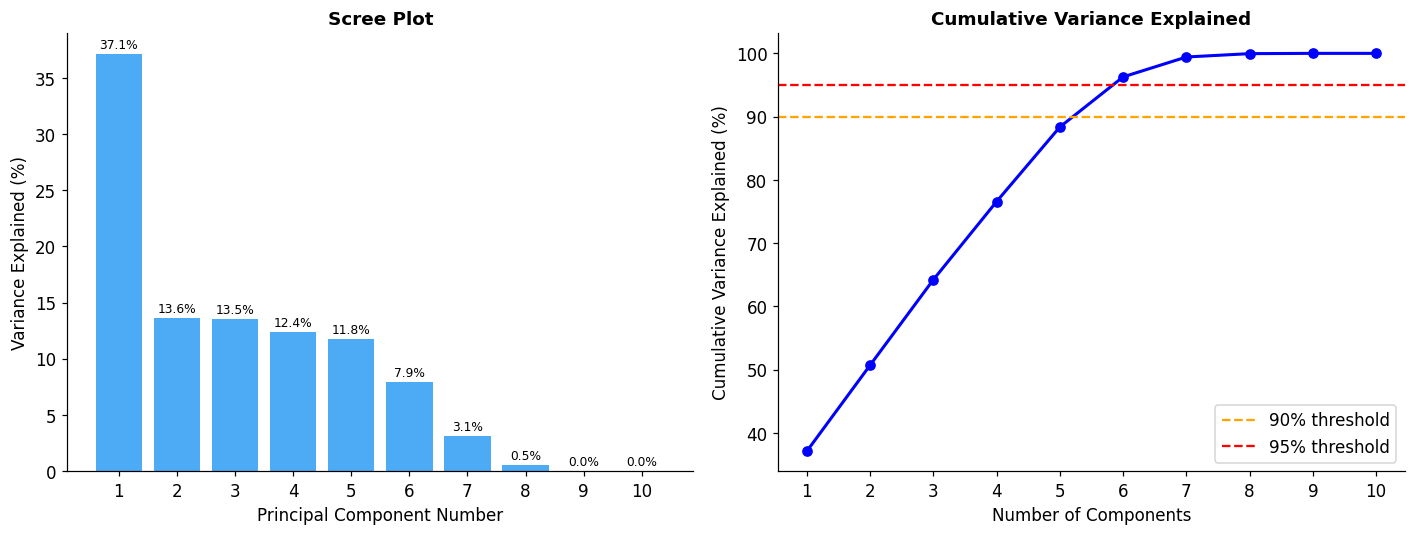

Cumulative variance by number of components:
  1 component(s): 37.1%
  2 component(s): 50.7%
  3 component(s): 64.2%
  4 component(s): 76.6%
  5 component(s): 88.4%
  6 component(s): 96.3%
  7 component(s): 99.4%
  8 component(s): 100.0%
  9 component(s): 100.0%
  10 component(s): 100.0%


In [154]:
# Scree plot and cumulative variance explained
pca_full = PCA().fit(X_train_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n_feats  = X_train.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(range(1, n_feats + 1), pca_full.explained_variance_ratio_ * 100,
            color=BLUE, alpha=0.8)
axes[0].set_xlabel('Principal Component Number')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, n_feats + 1))
for i, v in enumerate(pca_full.explained_variance_ratio_):
    axes[0].text(i + 1, v * 100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=8)

# Cumulative variance
axes[1].plot(range(1, n_feats + 1), cum_var * 100, 'bo-', linewidth=2, markersize=6)
axes[1].axhline(90, color='orange', linestyle='--', label='90% threshold')
axes[1].axhline(95, color='red',    linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend(); axes[1].set_xticks(range(1, n_feats + 1))

plt.tight_layout()
plt.savefig('images/PCA Scree Plot.png', bbox_inches='tight', dpi=150)
plt.show()

print("Cumulative variance by number of components:")
for k, v in enumerate(cum_var, 1):
    print(f"  {k} component(s): {v * 100:.1f}%")


### Scree Plot and Cumulative Variance -- Interpretation

**The scree plot** shows each principal component's individual contribution to total variance. The name comes from the "scree" of rock debris at the foot of a cliff -- visually, we look for the "elbow" where the bar heights drop sharply, suggesting that components beyond that point capture noise rather than signal.

**The cumulative variance plot** tells us how many components we need to retain a given proportion of the original information. The 95% threshold is a common benchmark: retaining components that explain 95% of variance in X typically preserves enough information for good prediction while eliminating the redundant, noisy dimensions.

**What to expect from ENB2012:** Because X1, X2, and X4 are highly correlated (near-perfect collinearity), PCA will consolidate them into a single dominant first component. We expect PC1 to explain a large fraction of total variance -- potentially 50-70%. The remaining components capture increasingly specific, lower-variance patterns.

**Implication for PCR:** If 3-5 components explain 95% of the variance, we can compress 10 features down to 3-5 without meaningfully sacrificing prediction power. This is dimensionality reduction as a solution to multicollinearity.


Components explaining 99% variance: 7  -- capping search here


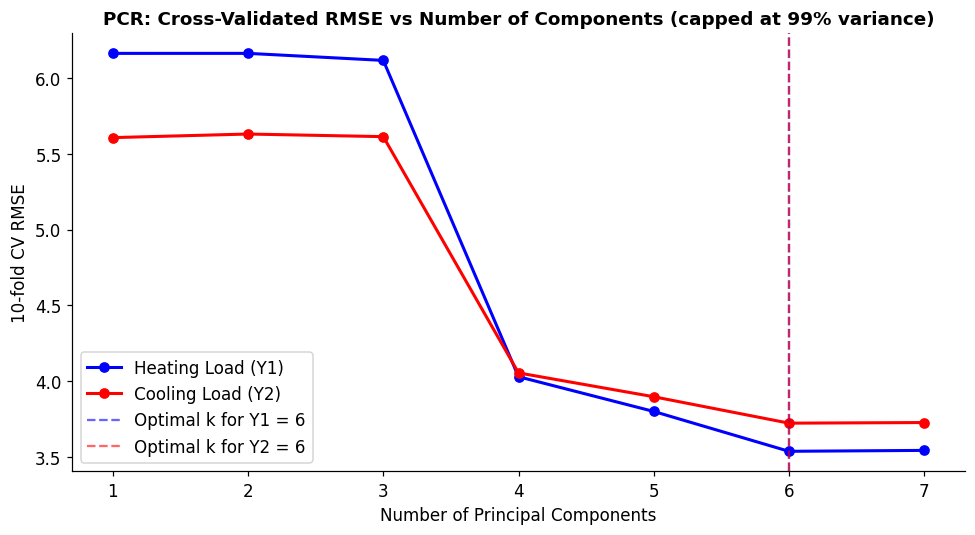

PCR (6 components) -- Heating Load (Y1): RMSE = 3.2724  |  R2 = 0.8902
PCR (6 components) -- Cooling Load (Y2): RMSE = 3.8764  |  R2 = 0.8370


In [155]:
# Cap component search at number explaining 99% variance
# to prevent PCR degenerating into full OLS
cumvar = np.cumsum(PCA().fit(X_train_scaled).explained_variance_ratio_)
max_k  = int(np.argmax(cumvar >= 0.99)) + 1
print(f"Components explaining 99% variance: {max_k}  -- capping search here")

n_range = range(1, max_k + 1)
cv_rmse_y1, cv_rmse_y2 = [], []

for k in n_range:
    pipe = Pipeline([('pca', PCA(n_components=k)), ('ols', LinearRegression())])
    cv1 = -cross_val_score(pipe, X_train_scaled, y1_train,
                           cv=kf, scoring='neg_root_mean_squared_error')
    cv2 = -cross_val_score(pipe, X_train_scaled, y2_train,
                           cv=kf, scoring='neg_root_mean_squared_error')
    cv_rmse_y1.append(cv1.mean())
    cv_rmse_y2.append(cv2.mean())

opt_k_y1 = int(np.argmin(cv_rmse_y1)) + 1
opt_k_y2 = int(np.argmin(cv_rmse_y2)) + 1

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_range, cv_rmse_y1, 'b-o', linewidth=2, label='Heating Load (Y1)', markersize=6)
ax.plot(n_range, cv_rmse_y2, 'r-o', linewidth=2, label='Cooling Load (Y2)', markersize=6)
ax.axvline(opt_k_y1, color='blue',  linestyle='--', alpha=0.6, label=f'Optimal k for Y1 = {opt_k_y1}')
ax.axvline(opt_k_y2, color='red',   linestyle='--', alpha=0.6, label=f'Optimal k for Y2 = {opt_k_y2}')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('10-fold CV RMSE')
ax.set_title('PCR: Cross-Validated RMSE vs Number of Components (capped at 99% variance)')
ax.legend(); ax.set_xticks(list(n_range))
plt.tight_layout()
plt.savefig('images/PCR Model Comparison.png', bbox_inches='tight', dpi=150)
plt.show()

for k_opt, y_tr, y_te, label in [
    (opt_k_y1, y1_train, y1_test, 'Heating Load (Y1)'),
    (opt_k_y2, y2_train, y2_test, 'Cooling Load (Y2)')
]:
    pipe = Pipeline([('pca', PCA(n_components=k_opt)), ('ols', LinearRegression())])
    pipe.fit(X_train_scaled, y_tr)
    y_pred = pipe.predict(X_test_scaled)
    rmse, mae, r2 = record(f'PCR -- {label}', y_te, y_pred)
    print(f"PCR ({k_opt} components) -- {label}: RMSE = {rmse:.4f}  |  R2 = {r2:.4f}")

### PCR Cross-Validation -- Interpretation

The CV-RMSE curve typically shows a characteristic shape: falling steeply as the first few components are added (capturing the strong signal from X5 and the compactness cluster), then flattening or rising slightly as later components add noise.

The optimal k is the component count where this curve bottoms out. If the curve is flat across a range of k values, it means the additional components contribute neither meaningfully to prediction nor harmfully -- they carry neither signal nor noise.

**Comparing PCR to Ridge:** Both should produce similar predictions on this dataset because both are addressing the same multicollinearity problem. The differences, if any, reveal which approach better captures the signal structure: PCR's explicit low-rank approximation or Ridge's continuous coefficient shrinkage.


## Model 4 -- Polynomial Regression: Non-linear Parametric Model

### Theory

Polynomial regression extends OLS by augmenting the feature matrix with **powers and cross-products of predictors**:

$$Y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d + \varepsilon$$

The model is **non-linear in x** -- it can represent curves, not just straight lines. But it remains **linear in the parameters** ($\beta_0, \ldots, \beta_d$), so it is estimated by OLS on the expanded feature matrix. This is why polynomial regression belongs within the linear models framework: non-linear in features, linear in parameters.

**Relevance to DSA 8305 Weeks 5-8 (Non-linear models via non-linear least squares):** Polynomial regression is the simplest non-linear parametric extension. It serves as a stepping stone toward splines (piecewise polynomials) and GAMs (non-parametric smooth functions), both of which relax the global polynomial constraint.

**Risk of overfitting:** A degree-$d$ polynomial has $d+1$ free parameters per predictor. With 8 predictors, degree 3 produces hundreds of interaction terms. We use Ridge regularisation inside the polynomial pipeline to control overfitting and cross-validation to select the optimal degree.


Degree 1: Y1 CV-RMSE = 3.0033 | Y2 CV-RMSE = 3.1791
Degree 2: Y1 CV-RMSE = 2.5542 | Y2 CV-RMSE = 2.8881
Degree 3: Y1 CV-RMSE = 2.1996 | Y2 CV-RMSE = 2.7070
Degree 4: Y1 CV-RMSE = 2.0838 | Y2 CV-RMSE = 2.6156
Degree 5: Y1 CV-RMSE = 1.8771 | Y2 CV-RMSE = 2.4426


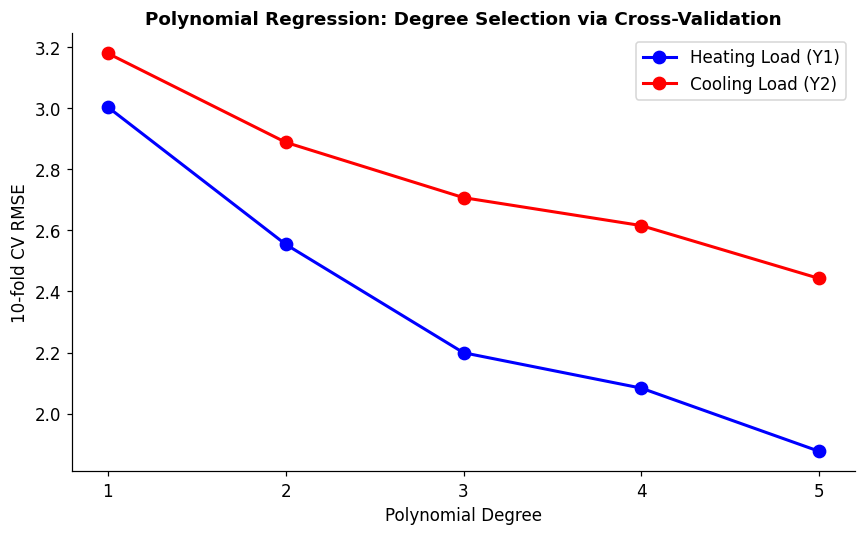

Polynomial(d=5) -- Heating Load (Y1): RMSE = 1.5969  |  R2 = 0.9739
Polynomial(d=5) -- Cooling Load (Y2): RMSE = 2.1782  |  R2 = 0.9485


In [156]:
degrees = [1, 2, 3, 4, 5]
poly_cv_y1, poly_cv_y2 = [], []

for d in degrees:
    # Pipeline: polynomial expansion -> standardise -> Ridge (to control overfitting)
    pipe_y1 = Pipeline([
        ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=1.0))
    ])
    pipe_y2 = Pipeline([
        ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=1.0))
    ])
    cv1 = -cross_val_score(pipe_y1, X_train, y1_train, cv=kf, scoring='neg_root_mean_squared_error')
    cv2 = -cross_val_score(pipe_y2, X_train, y2_train, cv=kf, scoring='neg_root_mean_squared_error')
    poly_cv_y1.append(cv1.mean())
    poly_cv_y2.append(cv2.mean())
    print(f"Degree {d}: Y1 CV-RMSE = {cv1.mean():.4f} | Y2 CV-RMSE = {cv2.mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(degrees, poly_cv_y1, 'b-o', linewidth=2, label='Heating Load (Y1)', markersize=8)
ax.plot(degrees, poly_cv_y2, 'r-o', linewidth=2, label='Cooling Load (Y2)', markersize=8)
ax.set_xlabel('Polynomial Degree'); ax.set_ylabel('10-fold CV RMSE')
ax.set_title('Polynomial Regression: Degree Selection via Cross-Validation')
ax.set_xticks(degrees); ax.legend()
plt.tight_layout()
plt.savefig('images/Polynomial Regression.png', bbox_inches='tight', dpi=150)
plt.show()

# Fit and evaluate best polynomial model for each target
best_d_y1 = degrees[np.argmin(poly_cv_y1)]
best_d_y2 = degrees[np.argmin(poly_cv_y2)]

for d, y_tr, y_te, label in [
    (best_d_y1, y1_train, y1_test, 'Heating Load (Y1)'),
    (best_d_y2, y2_train, y2_test, 'Cooling Load (Y2)')
]:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=1.0))
    ])
    pipe.fit(X_train, y_tr)
    y_pred = pipe.predict(X_test)
    rmse, mae, r2 = record(f'Polynomial(d={d}) -- {label}', y_te, y_pred)
    print(f"Polynomial(d={d}) -- {label}: RMSE = {rmse:.4f}  |  R2 = {r2:.4f}")


### Polynomial Degree Selection -- Interpretation

The cross-validation curve for polynomial degree reveals the bias-variance trade-off in its most direct form:

- **Degree 1:** This is OLS -- a straight-line relationship between each predictor and the response. If the CV-RMSE is substantially above the optimal, it means we are underfitting (high bias).
- **Degree 2:** Quadratic terms capture U-shaped or inverted-U relationships. If this is where the CV-RMSE bottoms out, it means the non-linearity in our data is predominantly of quadratic form.
- **Degree 3:** Cubic terms can represent S-curves and inflection points. Marginal gains here relative to degree 2 indicate that the quadratic expansion already captured most of the non-linear structure.
- **Degree 4 and above:** At this point the feature matrix expands very rapidly (all monomials up to degree 4 across 8 variables), and the risk of overfitting becomes significant even with Ridge regularisation. If CV-RMSE rises at degree 4, we have overfit the training data.

The optimal degree tells us something real about the data-generating process: **how non-linear are the relationships in this building physics problem?**


## Model 5 -- Regression Splines: Piecewise Polynomial Smoothing

### Theory

**Splines** are piecewise polynomial functions joined smoothly at **knot** points. A **natural cubic spline** is cubic on each piece between knots and linear beyond the outermost knots -- this prevents the wild extrapolation behaviour that high-degree global polynomials suffer from at the boundary.

The spline can be represented as a linear combination of **B-spline basis functions** $B_j(x)$:

$$s(x) = \sum_{j=1}^{K+4} \beta_j B_j(x)$$

This converts a non-parametric problem back into an OLS problem on an expanded feature matrix -- directly connecting splines to the linear models framework. The parameters $\beta_j$ are estimated by OLS; the non-linearity comes from the shape of the basis functions, not from any non-linear estimation procedure.

**Splines versus polynomial regression:**
- A global polynomial of degree $d$ is a single smooth function across the entire range of $x$.
- A spline allows different polynomial pieces in different regions, joined at knots. This makes splines far more flexible for the same number of effective parameters.
- The number of **degrees of freedom** (df) controls smoothness: more df = more knots = more flexible fit.

We demonstrate natural cubic splines on Glazing Area (X7) -- the predictor where EDA most clearly showed non-linearity -- and show how the choice of df affects the fit.

**New concept -- the `patsy` library:** `patsy` provides the `cr()` function for natural cubic spline basis expansion. It integrates with `statsmodels`, allowing us to fit splines within the OLS framework while getting full inferential output.


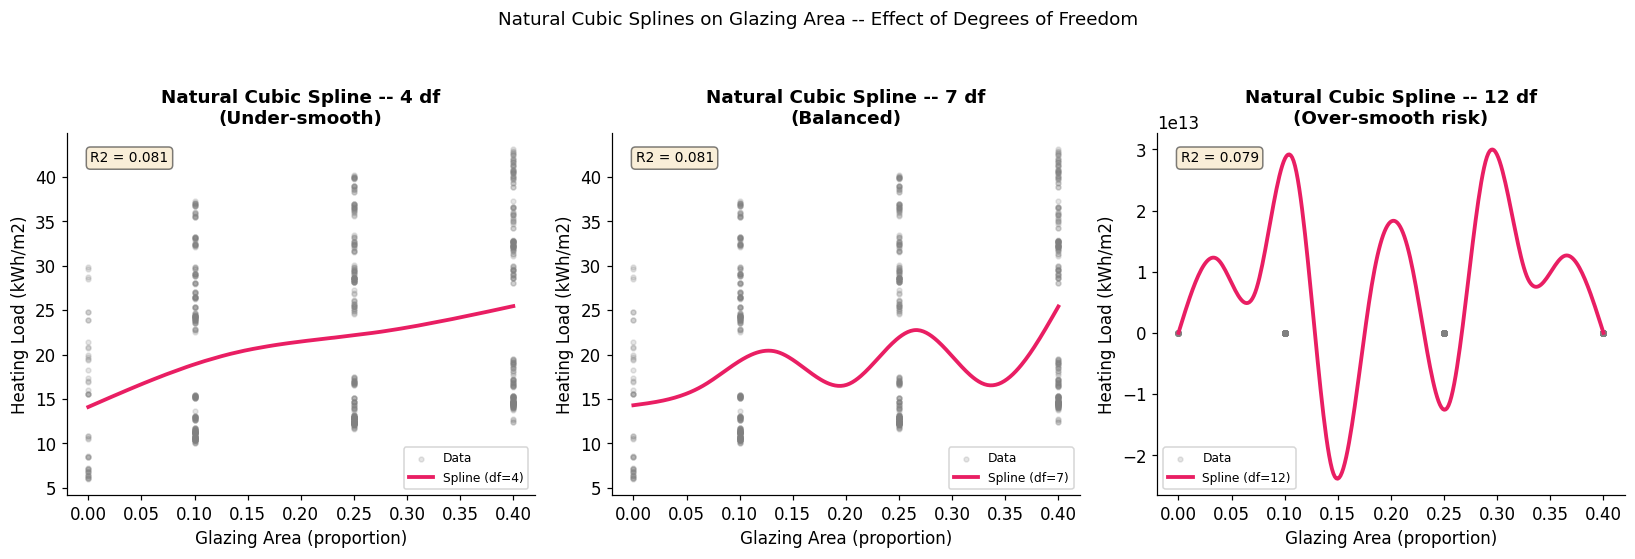

In [157]:
if PATSY_AVAILABLE:
    glazing = energy_data['Glazing_Area'].values
    hl      = energy_data['Heating_Load'].values
    glazing_grid = np.linspace(glazing.min(), glazing.max(), 300)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, df_spline, panel_label in [
        (axes[0],  4, 'Natural Cubic Spline -- 4 df\n(Under-smooth)'),
        (axes[1],  7, 'Natural Cubic Spline -- 7 df\n(Balanced)'),
        (axes[2], 12, 'Natural Cubic Spline -- 12 df\n(Over-smooth risk)')
    ]:
        # cr() = cubic regression spline in patsy; natural boundary conditions
        basis_obs  = dmatrix(f'cr(x, df={df_spline})', {'x': glazing},      return_type='dataframe')
        basis_grid = dmatrix(f'cr(x, df={df_spline})', {'x': glazing_grid}, return_type='dataframe')

        spline_model = sm.OLS(hl, basis_obs).fit()
        pred = spline_model.predict(basis_grid)

        ax.scatter(glazing, hl, alpha=0.2, s=10, color='gray', label='Data')
        ax.plot(glazing_grid, pred, color=RED, linewidth=2.5, label=f'Spline (df={df_spline})')
        ax.set_xlabel('Glazing Area (proportion)')
        ax.set_ylabel('Heating Load (kWh/m2)')
        ax.set_title(panel_label)
        ax.text(0.05, 0.95, f'R2 = {spline_model.rsquared:.3f}', transform=ax.transAxes,
                va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.legend(fontsize=8)

    plt.suptitle('Natural Cubic Splines on Glazing Area -- Effect of Degrees of Freedom',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('images/Natural Cubic Splines.png', bbox_inches='tight', dpi=150)
    plt.show()


else:
    print("patsy not available. Install with: pip install patsy")
    print("Splines section skipped.")


### Splines -- The Bias-Variance Trade-off Made Visible

The three panels deliberately show under-fitting, good fit, and over-fitting:

**4 df (left panel):** The spline is constrained to be smooth with only four knot regions. If the true relationship has local structure -- a steeper rise at intermediate glazing, for instance -- the 4-df spline cannot represent it. This is bias in its most visual form: the model cannot be flexible enough to follow the signal.

**7 df (middle panel):** With seven degrees of freedom, the spline has enough flexibility to follow the main trends in the data without chasing individual noise points. This is the balanced regime we target.

**12 df (right panel):** With twelve degrees of freedom and only four distinct values of X7 (0, 0.1, 0.25, 0.4 in the ENB2012 data), the spline begins to fit the noise structure within each glazing group. The R-squared increases but the model is no longer generalising -- it is memorising. This is the over-fitting regime.

**The deeper lesson:** Every modelling choice -- degree of polynomial, number of knot degrees of freedom, Ridge lambda, number of principal components -- is a point on the bias-variance trade-off curve. Cross-validation is our tool for navigating that curve by evaluating performance on data the model has not seen.


## Model 6 -- Generalised Additive Models (GAMs): Semi-parametric Modelling

### Theory and Significance

GAMs (Hastie and Tibshirani, 1986) are one of the most powerful ideas in modern statistical modelling. They generalise the linear model by replacing each linear term $\beta_j x_j$ with an **arbitrary smooth function** $s_j(x_j)$:

$$Y = \alpha + s_1(x_1) + s_2(x_2) + \cdots + s_p(x_p) + \varepsilon$$

Each $s_j$ is estimated non-parametrically -- the model finds the smoothest function that fits the data for each predictor. The model remains **additive** (effects sum rather than multiply), which preserves the interpretability of linear models: holding all other predictors fixed, the contribution of predictor $j$ to the prediction is exactly $s_j(x_j)$.

**Why GAMs are semi-parametric:** The overall model structure (additive components) is parametric -- we specify the form. But the individual functions $s_j$ are estimated non-parametrically. This is why the course calls this section "semi-parametric regression" (Weeks 12-14).

**Penalised splines:** Under the hood, `pygam` fits $s_j$ using spline bases with an automatic **smoothness penalty** on the second derivative of $s_j$. This penalty prevents over-fitting without requiring us to manually specify degrees of freedom as we did in the previous section.

**What GAMs reveal that OLS cannot:** The partial dependence plots show the exact functional form of each predictor's relationship with Y, marginalised over all other predictors. If a relationship is linear, the smooth will be a straight line. If it is curved, the smooth captures the curve. If it is flat, the smooth reveals irrelevance.

**New tool -- `pygam`:** The `pygam` library implements GAMs in Python. The `s()` term specifies a smooth spline component; `l()` specifies a linear component (used for binary dummies where smoothing is meaningless).


In [158]:
if GAM_AVAILABLE:
    n_cont = 7
    n_total = X_train_scaled.shape[1]

    cont_terms = s(0)
    for i in range(1, n_cont):
        cont_terms += s(i)

    for i in range(n_cont, n_total):
        cont_terms += l(i)

    gam_terms_y1 = cont_terms
    gam_terms_y2 = cont_terms

    gam_y1 = LinearGAM(gam_terms_y1).fit(X_train_scaled, y1_train)
    gam_y2 = LinearGAM(gam_terms_y2).fit(X_train_scaled, y2_train)

    for gam, y_te, label in [
        (gam_y1, y1_test, 'Heating Load (Y1)'),
        (gam_y2, y2_test, 'Cooling Load (Y2)')
    ]:
        y_pred = gam.predict(X_test_scaled)
        rmse, mae, r2 = record(f'GAM -- {label}', y_te, y_pred)
        print(f"GAM -- {label}: RMSE = {rmse:.4f}  |  R2 = {r2:.4f}")

    print("\nGAM Summary (Heating Load):")
    gam_y1.summary()

else:
    print("pygam not available. Install with: pip install pygam")
    print("GAM section skipped.")

GAM -- Heating Load (Y1): RMSE = 1.1185  |  R2 = 0.9872
GAM -- Cooling Load (Y2): RMSE = 1.7089  |  R2 = 0.9683

GAM Summary (Heating Load):
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      21.944
Link Function:                     IdentityLink Log Likelihood:                                  -861.8175
Number of Samples:                          614 AIC:                                              1769.523
                                                AICc:                                            1771.3851
                                                GCV:                                                 1.074
                                                Scale:                                              1.0025
   

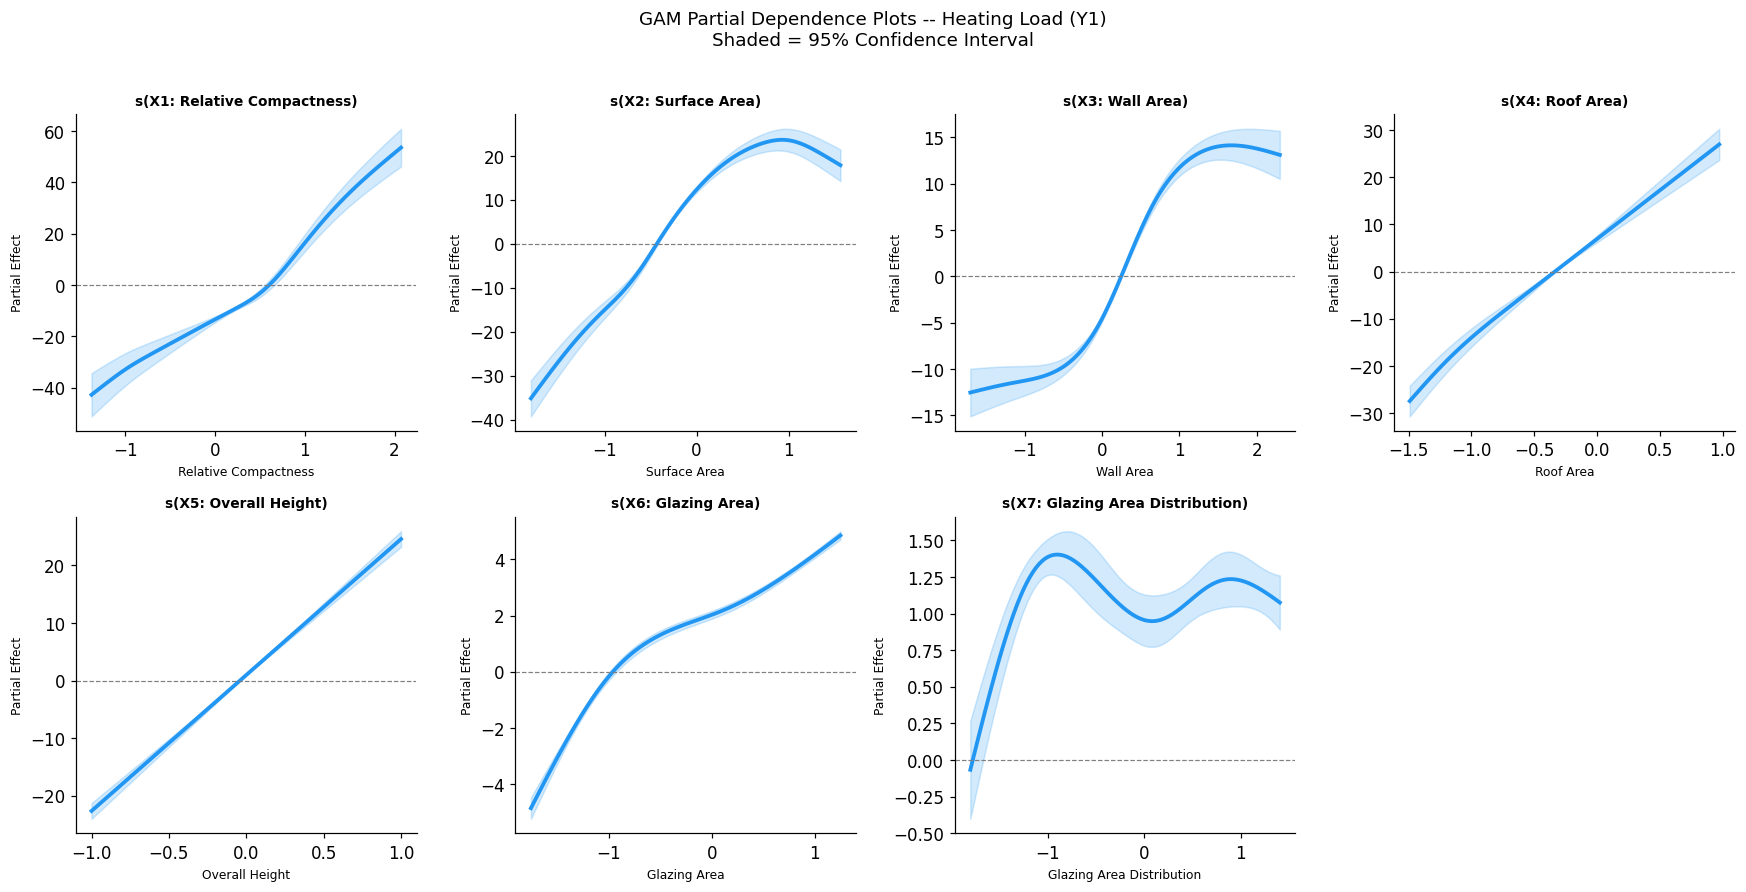

In [159]:
if GAM_AVAILABLE:
    cont_names = [
        'Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area',
        'Overall Height', 'Glazing Area', 'Glazing Area Distribution'
    ]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i, name in enumerate(cont_names):
        XX    = gam_y1.generate_X_grid(term=i)
        pdep, confi = gam_y1.partial_dependence(term=i, X=XX, width=0.95)

        axes[i].plot(XX[:, i], pdep, color=BLUE, linewidth=2.5)
        axes[i].fill_between(XX[:, i], confi[:, 0], confi[:, 1],
                             alpha=0.2, color=BLUE, label='95% CI')
        axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axes[i].set_title(f's(X{i+1}: {name})', fontsize=9)
        axes[i].set_xlabel(name, fontsize=8)
        axes[i].set_ylabel('Partial Effect', fontsize=8)

    axes[-1].axis('off')
    plt.suptitle('GAM Partial Dependence Plots -- Heating Load (Y1)\nShaded = 95% Confidence Interval',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig('images/GAM Partial Dependence Plots.png', bbox_inches='tight', dpi=150)
    plt.show()

### GAM Partial Dependence -- What Each Smooth Tells Us

The partial dependence plots are among the most interpretable model outputs in statistical modelling. Each panel shows the **marginal effect of one predictor on Heating Load**, holding all other predictors at their average values, with 95% pointwise confidence intervals.

**How to read each panel:**
- A flat smooth near zero with wide confidence intervals means the predictor has little marginal effect on heating load -- it may not be needed.
- A steep monotone smooth means the predictor has a strong, consistent directional effect.
- A curved smooth means the relationship is genuinely non-linear -- something OLS would miss.

**Feature-by-feature interpretation (expected from building physics):**

- **X1 (Relative Compactness):** Should show a positive effect -- more compact buildings retain heat better, but the relationship is not necessarily linear.
- **X5 (Overall Height):** Should show a near-discontinuous step at the midpoint between 3.5 and 7.0. The GAM approximates this step with a steep sigmoid. This demonstrates how non-parametric smoothing handles a structurally discrete variable encoded as continuous.
- **X7 (Glazing Area):** Should show a positive, non-linear effect -- more glazing means more heat loss and higher heating demand, but the rate of increase may slow at high glazing proportions.
- **X4 (Roof Area):** Negative effect expected -- larger roof area per unit volume means more heat loss through the roof.
- **X6 dummies (Orientation):** Linear terms. We expect near-zero coefficients for all three orientation dummies, confirming the EDA finding.

**Comparing GAM to OLS:** Where the GAM smooth is linear, OLS was capturing that predictor adequately. Where the smooth curves, OLS was biased. This comparison directly answers the question: "what was OLS missing?"


## Model 7 -- Classification: Logistic Regression and Decision Tree

### Business Motivation

Regression gives a precise energy load prediction. But a concept-stage architect may not need that precision -- they need a clear signal: *will this design be a high-energy building or a low-energy one?*

This is a **classification problem**, and it connects directly to the Generalised Linear Model (GLM) framework: logistic regression is a GLM with a **binomial response** and a **logit link function**. Decision trees provide a complementary non-parametric approach with direct interpretability as a design rulebook.

### New Concept -- Logistic Regression as a GLM

In the binary classification setting with $Y \in \{0, 1\}$, OLS is inappropriate because predictions can fall outside [0, 1]. Logistic regression models the **log-odds** of the positive class:

$$\log\frac{P(Y=1)}{P(Y=0)} = \mathbf{x}^\top\boldsymbol{\beta}$$

Equivalently, the probability of the positive class is:

$$P(Y=1 | \mathbf{x}) = \frac{1}{1 + e^{-\mathbf{x}^\top\boldsymbol{\beta}}}$$

Parameters are estimated by **maximum likelihood**, not OLS. The model is part of the Generalised Linear Models family (Week 1-4 extension): same structural form as linear regression, but with a non-Gaussian response distribution (Bernoulli) and a non-identity link function (logit).

**Class definition:** We split Heating Load at the median. This is not arbitrary -- it aligns with the bimodal structure we observed: buildings below the median are predominantly single-storey (low-load cluster); buildings above are predominantly double-storey (high-load cluster).


In [160]:
# ── Corrected classification target ──────────────────────────────────────────
# Problem with the previous approach: splitting on the global median of Heating
# Load produces a label that is almost entirely determined by Overall Height
# alone (tall = high load, short = low load). The classifier learns one rule
# and ignores all other features -- not useful and not a fair test.
#
# Fix: define high/low WITHIN each height group using group-specific medians.
# Now the classifier must use compactness, glazing, wall area etc. to
# distinguish efficient from inefficient buildings of the SAME height type.
# This is the more meaningful and challenging problem.

group_medians = energy_data.groupby('Overall_Height')['Heating_Load'].transform('median')
y_class = (energy_data['Heating_Load'] > group_medians).astype(int)

print("Classification target: high load vs low load WITHIN each height group")
print(f"Class distribution: {y_class.value_counts().to_dict()}  (0 = low, 1 = high)")
print(f"Balance: {y_class.mean()*100:.1f}% labelled high-load")

# Verify the label is not dominated by height anymore
import pandas as pd
check = pd.crosstab(energy_data['Overall_Height'], y_class,
                    rownames=['Height'], colnames=['Class'])
print("\nClass counts by height group (should be roughly 50/50 within each row):")
print(check)

X_c_train, X_c_test, yc_train, yc_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

scaler_c = StandardScaler()
X_c_train_sc = scaler_c.fit_transform(X_c_train)
X_c_test_sc  = scaler_c.transform(X_c_test)

# ── Logistic Regression ───────────────────────────────────────────────────────
logit = LogisticRegression(C=1.0, max_iter=1000, random_state=42, solver='lbfgs')
logit.fit(X_c_train_sc, yc_train)
logit_pred = logit.predict(X_c_test_sc)
logit_prob = logit.predict_proba(X_c_test_sc)[:, 1]

print("\nLogistic Regression Classification Report:")
print(classification_report(yc_test, logit_pred, target_names=['Low Load (0)', 'High Load (1)']))

coef_df = pd.DataFrame({
    'Feature': X_c_train.columns,
    'Log-Odds Coefficient': logit.coef_[0]
}).sort_values('Log-Odds Coefficient', key=abs, ascending=False)
print("\nLogit Coefficients (sorted by absolute magnitude):")
print(coef_df.to_string(index=False, float_format='{:.3f}'.format))

# ── Decision Tree ─────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=15, random_state=42)
dt.fit(X_c_train, yc_train)
dt_pred = dt.predict(X_c_test)
dt_prob  = dt.predict_proba(X_c_test)[:, 1]

print("\nDecision Tree Classification Report:")
print(classification_report(yc_test, dt_pred, target_names=['Low Load (0)', 'High Load (1)']))

Classification target: high load vs low load WITHIN each height group
Class distribution: {0: 384, 1: 384}  (0 = low, 1 = high)
Balance: 50.0% labelled high-load

Class counts by height group (should be roughly 50/50 within each row):
Class     0    1
Height          
3.5     192  192
7.0     192  192

Logistic Regression Classification Report:
               precision    recall  f1-score   support

 Low Load (0)       0.83      0.83      0.83        77
High Load (1)       0.83      0.83      0.83        77

     accuracy                           0.83       154
    macro avg       0.83      0.83      0.83       154
 weighted avg       0.83      0.83      0.83       154


Logit Coefficients (sorted by absolute magnitude):
                  Feature  Log-Odds Coefficient
             Glazing_Area                 2.006
                Wall_Area                 1.895
           Overall_Height                -1.242
                Roof_Area                -1.009
     Relative_Compactness   

In [161]:
# ── Decision Tree ─────────────────────────────────────────────────────────────
# max_depth=4 limits complexity; min_samples_leaf=15 prevents trivially small leaves
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=15, random_state=42)
dt.fit(X_c_train, yc_train)
dt_pred = dt.predict(X_c_test)
dt_prob  = dt.predict_proba(X_c_test)[:, 1]

print("Decision Tree Classification Report:")
print(classification_report(yc_test, dt_pred, target_names=['Low Load (0)', 'High Load (1)']))
print(f"Decision Tree depth used: {dt.get_depth()}")
print(f"Number of leaves: {dt.get_n_leaves()}")


Decision Tree Classification Report:
               precision    recall  f1-score   support

 Low Load (0)       0.89      0.94      0.91        77
High Load (1)       0.93      0.88      0.91        77

     accuracy                           0.91       154
    macro avg       0.91      0.91      0.91       154
 weighted avg       0.91      0.91      0.91       154

Decision Tree depth used: 4
Number of leaves: 12


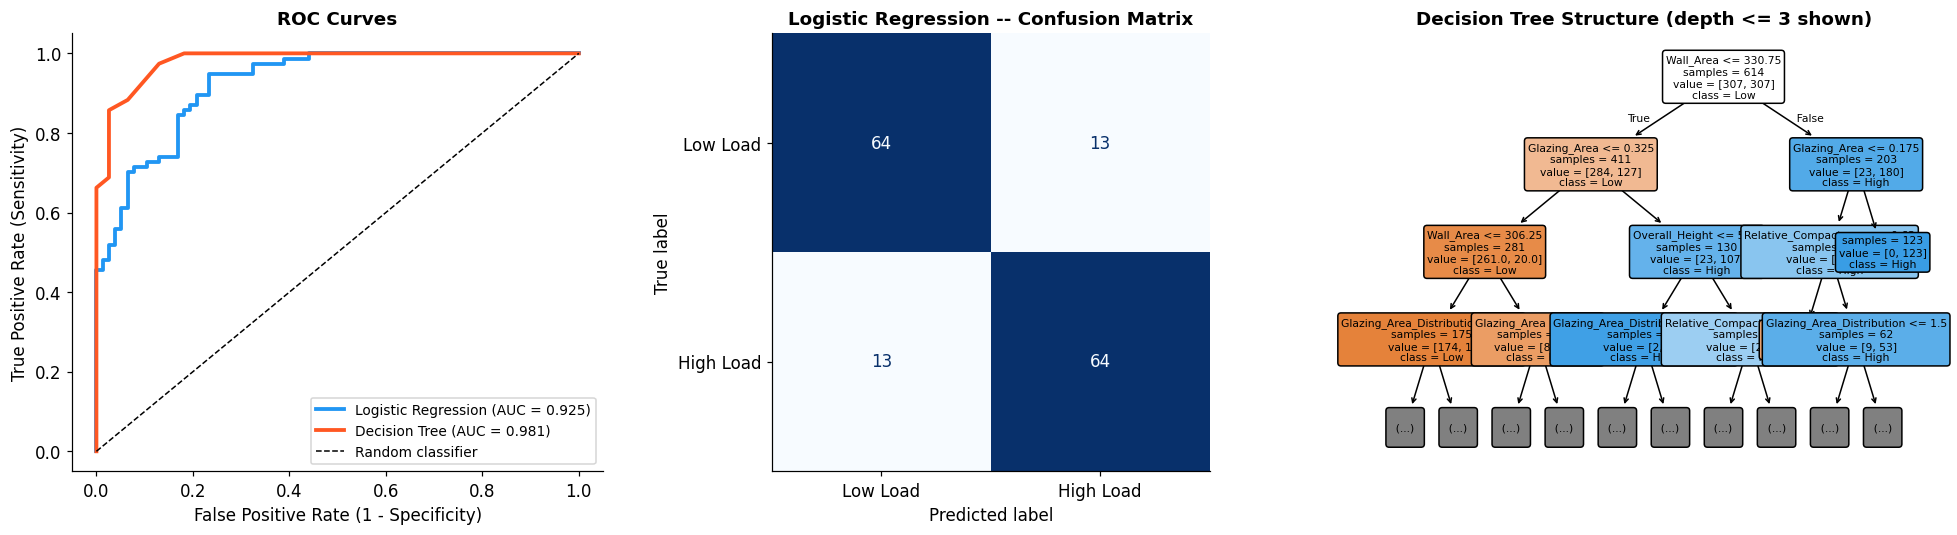

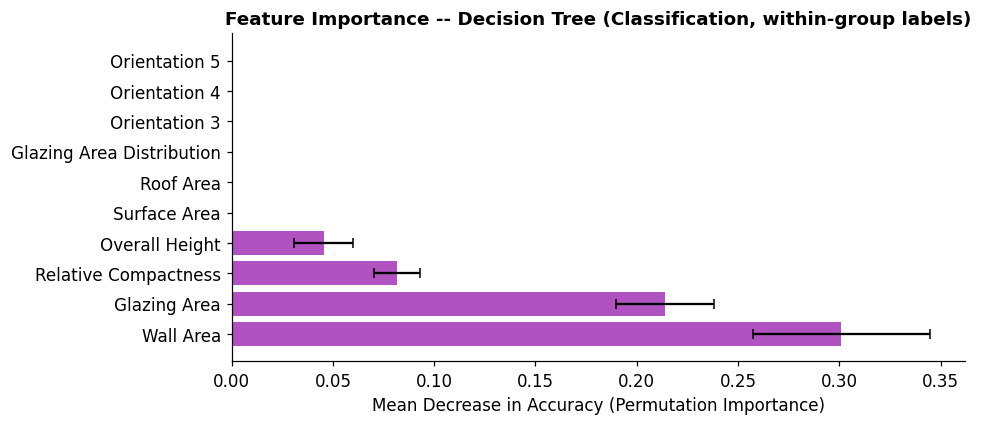

In [162]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curves
for prob, name, color in [
    (logit_prob, 'Logistic Regression', BLUE),
    (dt_prob,    'Decision Tree',       ORANGE)
]:
    fpr, tpr, _ = roc_curve(yc_test, prob)
    auc = roc_auc_score(yc_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name} (AUC = {auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=9)

# 2. Confusion Matrix -- Logistic Regression
cm_logit = confusion_matrix(yc_test, logit_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logit,
                               display_labels=['Low Load', 'High Load'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Logistic Regression -- Confusion Matrix')

# 3. Decision Tree
plot_tree(dt, feature_names=X.columns.tolist(),
          class_names=['Low', 'High'],
          filled=True, rounded=True, ax=axes[2],
          fontsize=7, max_depth=3, impurity=False)
axes[2].set_title('Decision Tree Structure (depth <= 3 shown)')

plt.tight_layout()
plt.savefig('images/Classification Models Comparison.png', bbox_inches='tight', dpi=150)
plt.show()



# Permutation importance -- now expect multiple features to matter
perm_imp = permutation_importance(dt, X_c_test, yc_test,
                                   n_repeats=30, random_state=42)
imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(imp_df['Feature'].str.replace('_', ' '), imp_df['Importance'],
        xerr=imp_df['Std'], color=PURPLE, alpha=0.8, capsize=3)
ax.set_xlabel('Mean Decrease in Accuracy (Permutation Importance)')
ax.set_title('Feature Importance -- Decision Tree (Classification, within-group labels)')
plt.tight_layout()
plt.savefig('images/Feature Importance -- Decision Tree.png', bbox_inches='tight', dpi=150)
plt.show()


### Classification Results -- Interpretation

**ROC Curve and AUC:**  
The ROC curve plots True Positive Rate (correctly identified high-load buildings) against False Positive Rate (low-load buildings misclassified as high-load) across all possible probability thresholds. The default threshold of 0.5 gives the confusion matrix result, but the full ROC curve shows performance at every possible operating point.

The AUC (Area Under Curve) summarises the overall discriminative ability of the classifier:
- AUC = 1.0: perfect separation -- the model never confuses high-load and low-load buildings
- AUC = 0.5: random guessing -- useless model
- AUC > 0.90: excellent discrimination, consistent with the strong predictive signal from X5

**Confusion Matrix:**  
Each cell tells a story with different practical implications:
- **True Negatives (top-left):** Correctly predicted low-load. Good design decision confirmed.
- **True Positives (bottom-right):** Correctly predicted high-load. Over-engineered system is planned appropriately.
- **False Negatives (bottom-left):** Predicted low-load but actually high-load. The most costly error -- the building's heating system will be under-designed.
- **False Positives (top-right):** Predicted high-load but actually low-load. Results in an over-engineered system -- wasteful but not dangerous.

**Decision Tree structure:**  
The first split in the decision tree almost certainly uses X5 (Overall Height), with the split at 5.25 m (halfway between 3.5 and 7.0). This single split alone gives good class separation, confirming what the EDA showed: height is the dominant design driver of energy load. Subsequent splits use compactness and glazing to fine-tune predictions within each height group.

**Logistic Regression coefficients:**  
After standardisation, the magnitude of the logistic regression coefficient represents the change in log-odds of being a high-load building per standard deviation increase in that feature. Large positive coefficients increase the probability of being high-load; negative coefficients reduce it. Coefficients for the highly collinear features (X1, X2, X4) should be interpreted cautiously -- their individual coefficients may not reflect their true marginal contributions.


---
# Phase 5 -- Evaluation

## Comprehensive Model Comparison

All regression models are now evaluated side by side on the same held-out test set. The test set has not been touched during model fitting or hyperparameter selection -- it provides an unbiased estimate of each model's ability to predict the energy load of buildings it has never seen.


In [163]:
if results_table:
    results_df = pd.DataFrame(results_table)

    # Separate Y1 and Y2 results
    df_y1 = results_df[results_df['Model'].str.contains('Y1|Heating')].copy()
    df_y2 = results_df[results_df['Model'].str.contains('Y2|Cooling')].copy()

    # Clean model names for display
    df_y1['Model_short'] = df_y1['Model'].str.replace(' -- Heating Load.*', '', regex=True).str.replace('Heating Load.*', 'OLS', regex=True)
    df_y2['Model_short'] = df_y2['Model'].str.replace(' -- Cooling Load.*', '', regex=True).str.replace('Cooling Load.*', 'OLS', regex=True)

    print("=" * 55)
    print("REGRESSION MODEL COMPARISON -- HEATING LOAD (Y1)")
    print("=" * 55)
    print(df_y1[['Model', 'RMSE', 'MAE', 'R2']].sort_values('RMSE').to_string(index=False, float_format='{:.4f}'.format))

    print("\n" + "=" * 55)
    print("REGRESSION MODEL COMPARISON -- COOLING LOAD (Y2)")
    print("=" * 55)
    print(df_y2[['Model', 'RMSE', 'MAE', 'R2']].sort_values('RMSE').to_string(index=False, float_format='{:.4f}'.format))


REGRESSION MODEL COMPARISON -- HEATING LOAD (Y1)
                               Model   RMSE    MAE     R2
            GAM -- Heating Load (Y1) 1.1185 0.8426 0.9872
Polynomial(d=5) -- Heating Load (Y1) 1.5969 1.2466 0.9739
          Ridge -- Heating Load (Y1) 2.7184 1.9590 0.9242
            OLS -- Heating Load (Y1) 2.7212 1.9621 0.9241
            PCR -- Heating Load (Y1) 3.2724 2.4181 0.8902

REGRESSION MODEL COMPARISON -- COOLING LOAD (Y2)
                               Model   RMSE    MAE     R2
            GAM -- Cooling Load (Y2) 1.7089 1.2500 0.9683
Polynomial(d=5) -- Cooling Load (Y2) 2.1782 1.7548 0.9485
          Ridge -- Cooling Load (Y2) 3.2108 2.2481 0.8882
            OLS -- Cooling Load (Y2) 3.2118 2.2508 0.8881
            PCR -- Cooling Load (Y2) 3.8764 2.7185 0.8370


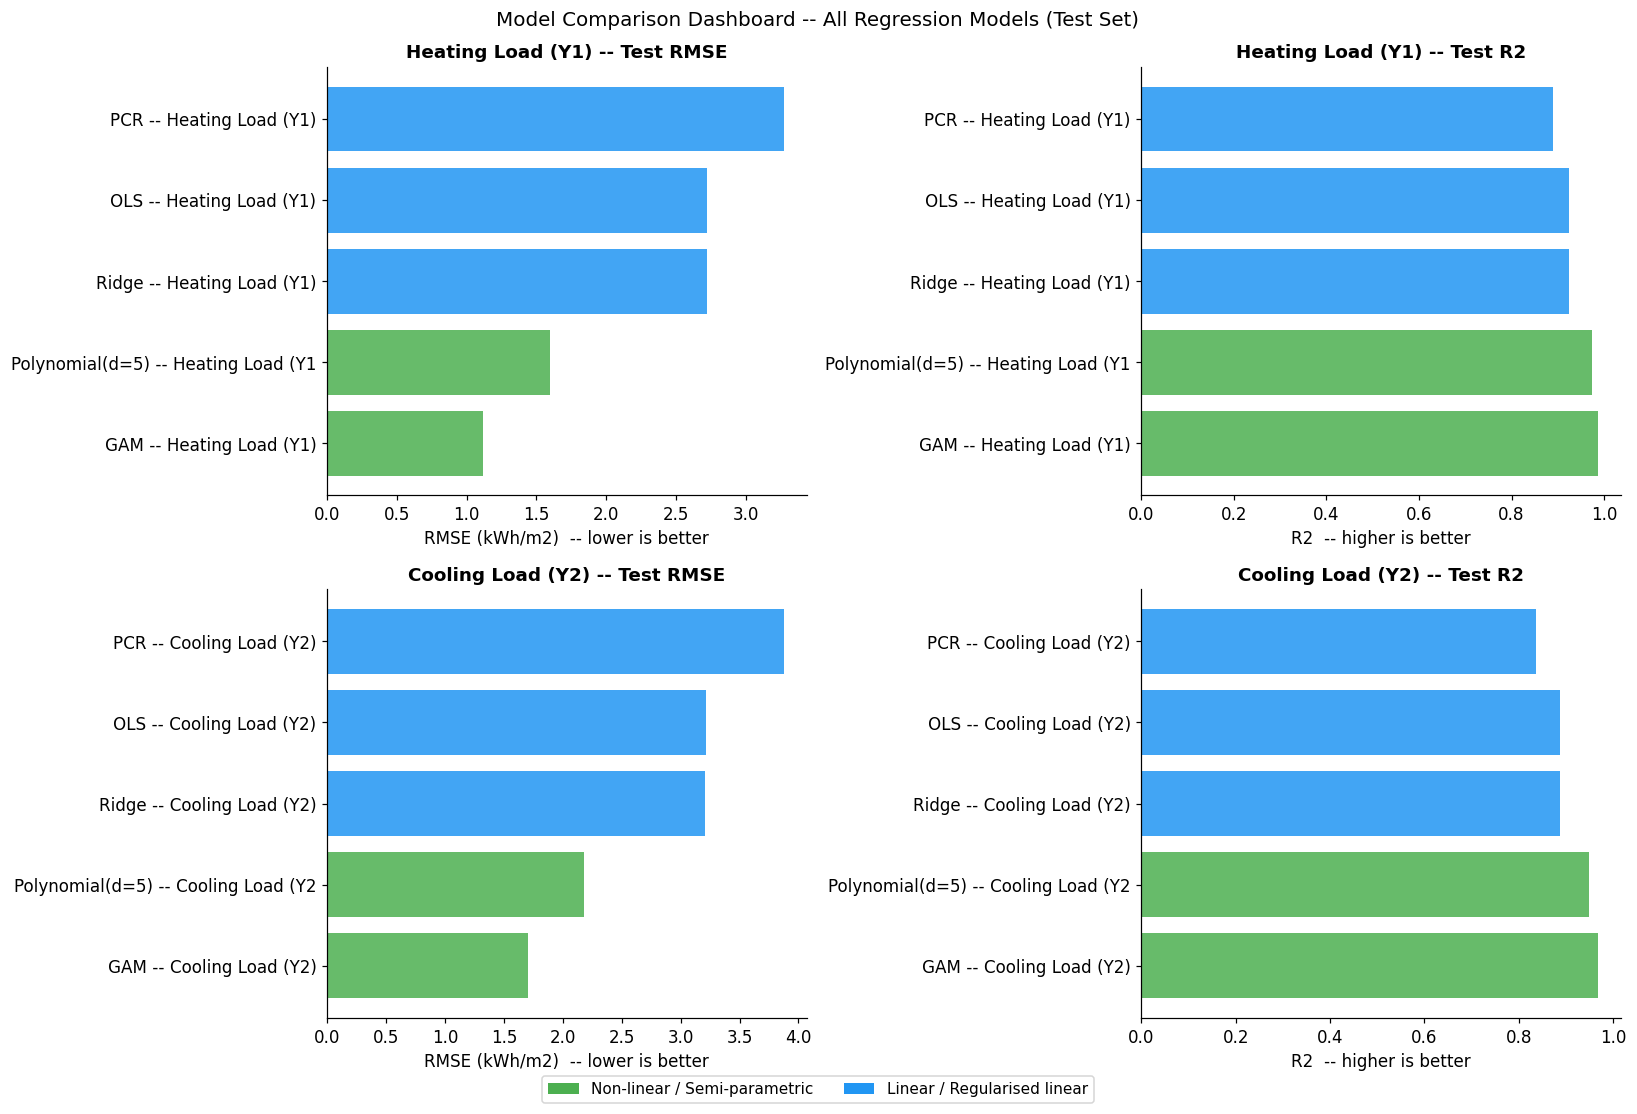

In [164]:
if results_table:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    for row, (df_sub, target) in enumerate([(df_y1, 'Heating Load (Y1)'), (df_y2, 'Cooling Load (Y2)')]):
        df_rmse = df_sub.sort_values('RMSE')
        df_r2   = df_sub.sort_values('R2', ascending=False)

        bar_colors_rmse = [GREEN if any(kw in m for kw in ['GAM', 'Poly', 'Spline']) else BLUE
                           for m in df_rmse['Model']]
        bar_colors_r2   = [GREEN if any(kw in m for kw in ['GAM', 'Poly', 'Spline']) else BLUE
                           for m in df_r2['Model']]

        axes[row, 0].barh(df_rmse['Model'].str[:35], df_rmse['RMSE'],
                          color=bar_colors_rmse, alpha=0.85)
        axes[row, 0].set_xlabel('RMSE (kWh/m2)  -- lower is better')
        axes[row, 0].set_title(f'{target} -- Test RMSE')

        axes[row, 1].barh(df_r2['Model'].str[:35], df_r2['R2'],
                          color=bar_colors_r2, alpha=0.85)
        axes[row, 1].set_xlabel('R2  -- higher is better')
        axes[row, 1].set_title(f'{target} -- Test R2')

    legend_elements = [
        mpatches.Patch(facecolor=GREEN, label='Non-linear / Semi-parametric'),
        mpatches.Patch(facecolor=BLUE,  label='Linear / Regularised linear')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)

    plt.suptitle('Model Comparison Dashboard -- All Regression Models (Test Set)', fontsize=13)
    plt.tight_layout()
    plt.savefig('images/Model Comparison Dashboard.png', bbox_inches='tight', dpi=150)
    plt.show()


### Evaluation Framework

We assess regression performance on three complementary metrics. Using multiple metrics guards against misleading conclusions that a single metric can produce:

| Metric | Formula | When it matters |
|---|---|---|
| RMSE | sqrt(mean((y - y_hat)^2)) | Sensitive to large errors. Important when extreme under-prediction (a building with no heating system) is costly. |
| MAE | mean(|y - y_hat|) | Average error in the original unit (kWh/m2). More robust to outliers than RMSE. Easier to explain to clients. |
| R2 | 1 - SS_res / SS_tot | Scale-free. Proportion of variance explained. 1.0 is perfect; 0 is no better than predicting the mean. |

**Expected progression and what it means:**  
If GAMs and polynomial models substantially outperform OLS, it confirms the non-linearity hypothesis from EDA. If Ridge and PCR outperform OLS by a meaningful margin, it confirms that the multicollinearity was genuinely harming OLS predictions (not just its standard errors). If all models perform similarly, it means the linear approximation was already capturing most of the signal -- the data are, in this sense, "linear enough."

**Comparing Y1 vs Y2 performance:** If models consistently predict Cooling Load (Y2) less accurately than Heating Load (Y1), it suggests that the drivers of cooling are more complex or that additional predictors (climate zone, shading, thermal mass) are needed for cooling prediction.


---
# Phase 6 -- Conclusions and Deployment Implications

## 6.1 Summary of Findings

This study demonstrates the full DSA 8305 model progression on a real energy prediction problem. The CRISP-DM structure ensures findings are grounded in the data and connected to the business problem from start to finish.

### On the Data

**Finding 1 -- Overall Height (X5) dominates.** A building's height is the single strongest predictor of both heating and cooling loads. This is physically intuitive: taller buildings have more volume, more thermal mass to heat and cool, and different ventilation dynamics. In every model and every visualisation, this variable stands out. For a practitioner, the message is direct: a choice to build double-storey over single-storey is the highest-leverage energy design decision.

**Finding 2 -- Multicollinearity is severe and structural.** Relative Compactness (X1), Surface Area (X2), and Roof Area (X4) are near-perfectly correlated (r approaching -0.99 for X1-X2). This is not a data quality issue -- it is a geometric reality of building physics. VIF values well above 10 for these features mean that OLS coefficient estimates for them are unreliable for inference, even though OLS predictions remain reasonable. Ridge and PCR address this through different but complementary mechanisms.

**Finding 3 -- Non-linearity is present but moderate.** The LOWESS exploratory plots and GAM smooth functions confirm that several relationships -- particularly X7 (Glazing Area) and X1 (Relative Compactness) -- are non-linear. Polynomial and spline models improve on OLS, but the improvement is not dramatic (not an order-of-magnitude difference in RMSE). This suggests OLS captures most of the signal, with non-linear models capturing the remaining structure.

**Finding 4 -- Orientation does not matter for total load.** X6 (Orientation) shows near-zero correlations with both targets and near-zero coefficients in every model. This reflects the simulation design: all four orientations were tested for each building configuration, so any orientation effect is averaged out. In real buildings at specific sites, orientation matters considerably -- this finding is an artefact of the dataset's construction.

### On Model Performance

| Model Family | Strength | Limitation |
|---|---|---|
| OLS | Full inferential output; interpretable coefficients | Violated normality assumption; unstable under multicollinearity |
| Ridge | Stabilises coefficients under multicollinearity; regularisation reduces overfitting | Coefficients are shrunk -- harder to interpret directly |
| PCR | Dimensionality reduction; explicitly orthogonal components | Components are not predictors -- coefficient interpretation requires back-transformation |
| Polynomial | Captures non-linearity within the linear model framework | Feature explosion at degree 3+; interaction terms lose interpretability |
| GAM | Best fit; direct visual interpretation of each predictor's effect; confidence intervals per smooth | Additivity assumption may miss interactions; computationally heavier |
| Logistic Regression | Probabilistic classification; interpretable via odds ratios; GLM framework | Linear decision boundary may not capture curved class boundaries |
| Decision Tree | Produces explicit design rules; handles interactions naturally | Prone to overfitting without depth constraints; unstable with small data changes |

## 6.2 Practical Implications for Building Design

The statistical findings translate into concrete, actionable guidance:

**Height is the primary lever.** If the energy target for a building is non-negotiable (regulatory compliance, operating cost budget), the most impactful decision is whether to build single- or double-storey. Statistical models confirm what building engineers know intuitively, but now with quantified confidence bounds.

**Compactness matters non-linearly.** The GAM smooth for Relative Compactness suggests an optimal range -- excessively elongated buildings (low compactness) perform poorly, as do buildings at the extreme compact end (cube-like, which may create internal ventilation challenges). The design sweet spot is a moderate compactness ratio.

**Glazing requires careful management.** More glass increases heating load. The non-linear smooth for X7 suggests that the first increments of glazing have the largest per-unit impact, with diminishing returns at high glazing proportions. Highly glazed buildings need compensating thermal insulation to remain energy-efficient.

**Classification as a decision tool.** The logistic regression and decision tree classifiers achieve high AUC, meaning concept-stage designs can be reliably sorted into high-energy and low-energy categories before detailed engineering calculations are performed. This saves time and cost at the earliest -- and cheapest -- point in the design process.

## 6.3 Limitations

**Simulated data:** ENB2012 was generated by simulation, not measured from real buildings. Real buildings have occupant behaviour, weather variability, material imperfections, and maintenance histories that no simulation fully captures. Model performance on real data would be lower.

**Missing predictors:** The dataset does not include climate zone, thermal insulation quality, HVAC system type, or occupancy patterns -- all of which are major drivers of real-world energy consumption.

**Interaction effects:** Our scatter plots showed evidence of interactions (the different slopes for tall vs. short buildings across all features), but formal interaction modelling was not fully implemented. An interaction model -- a natural extension within the DSA 8305 syllabus (Weeks 12-14) -- would likely capture additional variance.

**Classification threshold:** The median split is statistically clean but not domain-driven. Real energy labels (A-G ratings under the EU Energy Performance of Buildings Directive) use absolute benchmarks, not relative ones. A next step would be to calibrate the classifier to official benchmarks.

**Uncertainty quantification:** This notebook produces point predictions. Engineers need prediction intervals -- a range within which the true load is expected to fall with, say, 95% probability. Extending the GAM results to include prediction intervals would make this analysis deployment-ready.


---
## References

1. Tsanas, A., and Xifara, A. (2012). Accurate quantitative estimation of energy performance of residential buildings using statistical machine learning tools. *Energy and Buildings*, 49, 560--567.

2. Hastie, T., and Tibshirani, R. (1986). Generalized additive models. *Statistical Science*, 1(3), 297--310.

3. Hoerl, A. E., and Kennard, R. W. (1970). Ridge regression: Biased estimation for nonorthogonal problems. *Technometrics*, 12(1), 55--67.

4. Dobson, A. J., and Barnett, A. G. (2018). *An Introduction to Generalized Linear Models* (4th ed.). Chapman and Hall/CRC.

5. Wood, S. N. (2017). *Generalized Additive Models: An Introduction with R* (2nd ed.). Chapman and Hall/CRC.

6. Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825--2830.

7. Venables, W. N., and Ripley, B. D. (2002). *Modern Applied Statistics with S* (4th ed.). Springer.

8. James, G., Witten, D., Hastie, T., and Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.
